In [5]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d

from collections import defaultdict

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
mpl.rcParams.update(config)

import astropy
import astropy.units as u

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()


1102


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_within_coverage,grating_slitloss_correction,lines_fit,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}


---
## Binning the spectrum and average different attenuation spectrum.

In [2]:

group_conditions = [(-0.05,0.02), (0.02,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.45),(0.45,0.6)]

def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return 7

In [ ]:

group_keys = defaultdict(list)

# 2. 遍历 Catalog 进行分组 (只收集 ID，不加载数据)
print("Categorizing catalog entries...")
for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    try:
        # 获取参数
        uv_params = catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']
        line_params = catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']

        uv_slope_value = uv_params['exponent']
        halpha_flux = line_params['halpha_flux']
        hbeta_flux = line_params['hbeta_flux']

        # 计算巴耳末减缩
        # 注意：添加保护防止 hbeta 为 0 或负数导致 log 报错
        if hbeta_flux <= 0 or halpha_flux <= 0:
            continue

        balmer_decrement = np.log(halpha_flux / hbeta_flux / 2.86)

        # 获取组号
        group_index = group_condition_func(balmer_decrement)

        if group_index != -1:
            group_keys[group_index].append(surveyid_subid)

    except Exception as e:
        # 防止个别数据缺失导致整个循环中断
        continue

# 3. 初始化 Averager 字典并处理数据
averagers = {}

# 定义 Mask 区域 (你之前定义的)
mask_regions = [
    (3800, 4150),
    (4300, 4400),
    (4800, 5050),
    (5850, 5900),
    (6500, 6650),
    (6700, 6760),
    (7000, 7150),
    (7300, 7500)
]

# 遍历存在的组进行处理
# sorted(group_keys.keys()) 保证按顺序处理 0, 1, 2...
for group_idx in sorted(group_keys.keys()):
    keys = group_keys[group_idx]
    print(f"Processing Group {group_idx}: {len(keys)} spectra found.")

    if len(keys) == 0:
        continue

    # 实例化
    averager = FL.SpectrumAverager()

    # A. 批量加载
    # 注意：这里需要传入 load_func，即你用于读取 FITS 的函数
    # 假设你的读取函数叫 Load_Spectrum_From_Fits
    success = averager.load_spectrum_catalog(
        keys,
        DJAv4Catalog,
        load_func=FL.Load_Spectrum_From_Fits
    )

    if not success:
        print(f"  No valid spectra loaded for Group {group_idx}.")
        continue

    # B. 创建网格与插值
    averager.create_common_wavelength_grid(wavelength_range=(1350, 8000), grid_size=10)
    averager.interpolate_spectra(interpolation_method='linear')

    # C. 归一化 (使用区间归一化)
    averager.spectrum_normalization_within_range(wavelength_range=(5400, 5600), target_flux=1.e-19)

    # D. 计算平均谱 (此时生成的是 Raw Average)
    averager.compute_average_spectrum(
        method='median',
        ignore_nan=True,
        use_percentile_filter=True,
        lower_percentile=16,
        upper_percentile=84
    )

    # E. 应用 Emission Line Mask (新功能)
    averager.apply_emission_line_mask(mask_regions)

    # F. 保存结果到字典
    averagers[group_idx] = averager

    # G. 可选：保存到文件
    # averager.save_average_spectrum_to_file(f"output/average_spectrum_group_{group_idx}.npz")

print("All groups processed.")

Categorizing catalog entries...
Processing Group 0: 102 spectra found.
Applied masks to 8 regions.
Processing Group 1: 148 spectra found.
Applied masks to 8 regions.
Processing Group 2: 150 spectra found.
Applied masks to 8 regions.
Processing Group 3: 111 spectra found.
Applied masks to 8 regions.
Processing Group 4: 69 spectra found.
Applied masks to 8 regions.
Processing Group 5: 44 spectra found.
Applied masks to 8 regions.
Processing Group 7: 478 spectra found.
Applied masks to 8 regions.
All groups processed.


In [4]:
uv_slope_list=[]
uv_slope_err_list=[]
balmer_ratio_list=[]
balmer_ratio_err_list=[]
plotting_alpha_list=[]

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    best_SNR=-1
    best_Signal=None
    best_Noise=None
    best_key=None
    for key, dict_value in catalog['lines_fit'].items():

        balmer_decrement_uncertainty=FL.BalmerDecrementUncertainty(dict_value['halpha_flux'],dict_value['halpha_flux_err'],dict_value['hbeta_flux'],dict_value['hbeta_flux_err'])
        balmer_decrement=dict_value['halpha_flux']/dict_value['hbeta_flux']
        snr=abs(balmer_decrement/balmer_decrement_uncertainty)
        if snr>best_SNR:
            best_SNR=snr
            best_Signal=balmer_decrement
            best_Noise=balmer_decrement_uncertainty
            best_key=key
    if best_Signal is None:
        catalog['dust_curve_parameters']={}
        catalog['sample_flag']=False
        catalog['reason_for_exclusion'].append('No valid Balmer decrement measurement')
        DJAv4Catalog.update_catalog_item(surveyid_subid, catalog)
        continue

    balmer_ratio_list.append(best_Signal)
    balmer_ratio_err_list.append(best_Noise)


    uv_slope_list.append(catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent'])
    uv_slope_err_list.append(catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent_error'])

    if np.log(best_Signal/2.86)<-0.05:
        plotting_alpha_list.append(0.3)
    else:
        plotting_alpha_list.append(1.0)


uv_slope_array=np.array(uv_slope_list)
uv_slope_err_array=np.array(uv_slope_err_list)
balmer_ratio_array=np.array(balmer_ratio_list)
balmer_ratio_err_array=np.array(balmer_ratio_err_list)

balmer_decrement_array=np.log(balmer_ratio_array/(2.86))
balmer_decrement_uncertainty_array=balmer_ratio_err_array/balmer_ratio_array


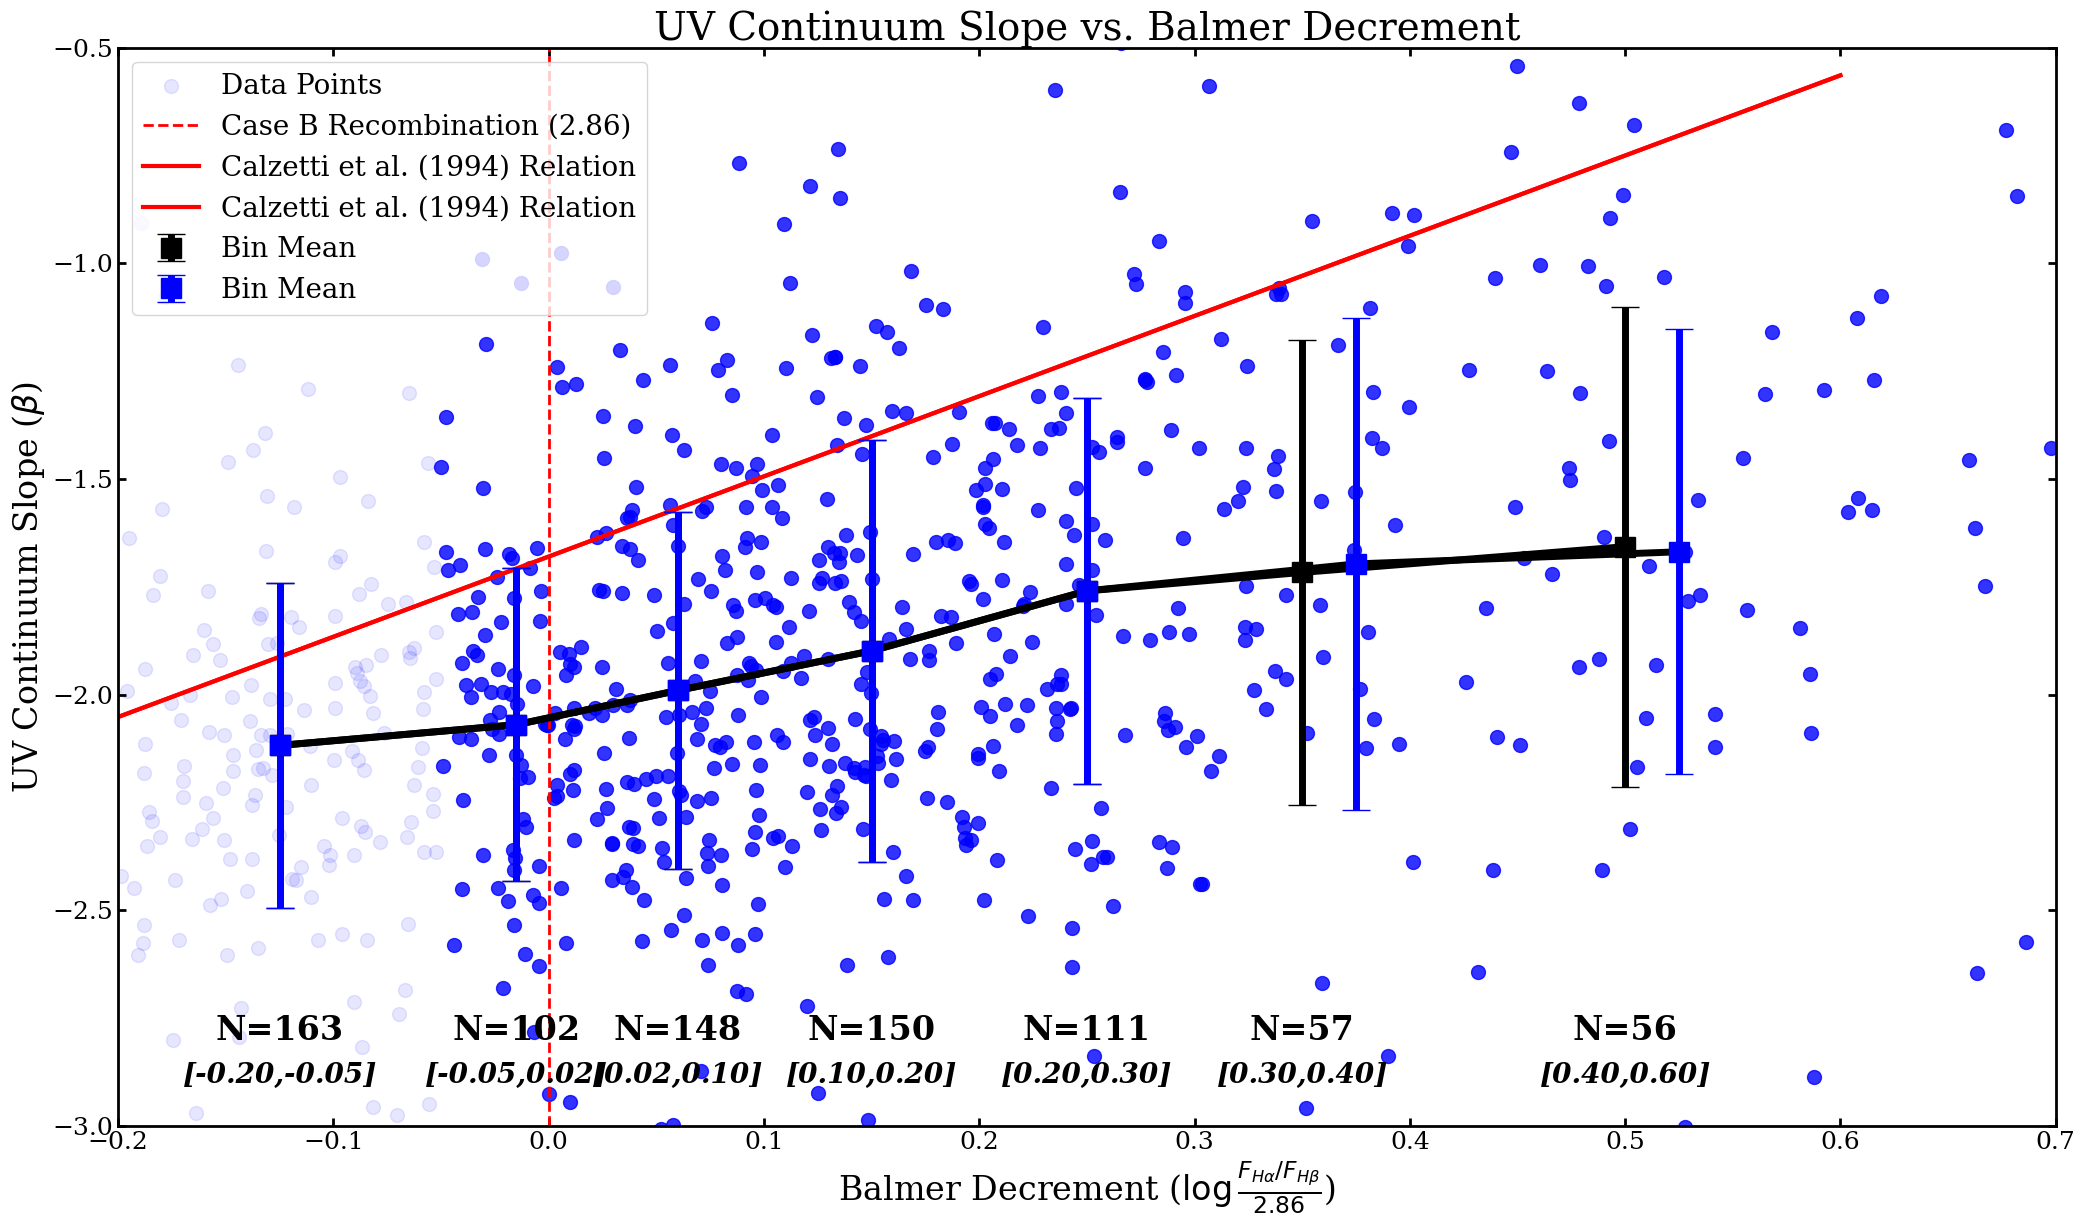

In [5]:


fig, ax = plt.subplots(figsize=(25,14))
# ax.errorbar(balmer_decrement_array, uv_slope_array,
#             xerr=balmer_decrement_uncertainty_array,
#             yerr=uv_slope_err_array,
#             fmt='o', ecolor='gray', capsize=2, markersize=10, label='Data Points')
for i in range(len(balmer_decrement_array)):
    ax.scatter(balmer_decrement_array[i], uv_slope_array[i],
                # xerr=balmer_decrement_uncertainty_array[i],
                # yerr=uv_slope_err_array[i],fmt='o', ecolor='gray', capsize=2,
                s=100,color='blue', label='Data Points' if i==0 else "", alpha=plotting_alpha_list[i]-0.2)
ax.set_xlabel(r'Balmer Decrement ($\log \frac{F_{H\alpha}/F_{H\beta}}{2.86}$)', fontsize=24)
ax.set_ylabel(r'UV Continuum Slope ($\beta$)', fontsize=24)
ax.set_title('UV Continuum Slope vs. Balmer Decrement', fontsize=28)
ax.axvline(x=0, color='red', linestyle='--', lw=2, label='Case B Recombination (2.86)')
ax.set_xlim(-0.2,0.7)
ax.set_ylim(-3,-0.5)


def calzetti(x):
    return 1.86*x-1.68
group_conditions = [(-0.05,0.02),(0.02,0.10), (0.10,0.2),(0.2,0.3),(0.3,0.40),(0.40,0.6)]
group_conditions = [(-0.2,-0.05),(-0.05,0.02), (0.02,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4),(0.4,0.6)]
last_point_x=None
last_point_y=None

for lower, upper in group_conditions:
    group_mask = (balmer_decrement_array >= lower) & (balmer_decrement_array < upper)
    group_num=np.sum(group_mask)
    if group_num == 0:
        continue
    group_uv_slopes = uv_slope_array[group_mask]
    group_uv_slope_errs = uv_slope_err_array[group_mask]

    lower_value=2.5
    upper_value=100-lower_value


    mask_lower_16_upper_84 = (group_uv_slopes >= np.percentile(group_uv_slopes,lower_value)) & (group_uv_slopes <= np.percentile(group_uv_slopes, upper_value))
    group_uv_slopes = group_uv_slopes[mask_lower_16_upper_84]


    weighted_mean_uv_slope = np.mean(group_uv_slopes)

    mid_point = (lower + upper) / 2
    z=30

    deviation = np.std(group_uv_slopes)

    # ax.scatter(mid_point, weighted_mean_uv_slope,
    #             marker='s', color='black', s=300,
    #             label=f'Bin Mean' if lower == group_conditions[0][0] else "", zorder=z)
    ax.errorbar(mid_point, weighted_mean_uv_slope,
                yerr=deviation,
                fmt='s', color='black', markersize=15,
                label=f'Bin Mean' if lower == group_conditions[0][0] else "", zorder=z, capsize=10, elinewidth=5)

    if last_point_x is not None and last_point_y is not None:
        ax.plot([last_point_x, mid_point], [last_point_y, weighted_mean_uv_slope], color='black', linewidth=5, zorder=z)
    last_point_x = mid_point
    last_point_y = weighted_mean_uv_slope

    plt.text(mid_point, -2.8, f'N={group_num}', fontsize=24, ha='center',zorder=z,c='black',fontweight='bold')
    plt.text(mid_point, -2.9, f'[{lower:.2f},{upper:.2f}]', fontsize=20, ha='center',zorder=z,c='black',fontstyle='italic',fontweight='bold')



x_values = np.linspace(-0.2, 0.6, 100)
y_values = calzetti(x_values)
ax.plot(x_values, y_values, color='red', linestyle='-', lw=3, label='Calzetti et al. (1994) Relation')
ax.legend(fontsize=20, loc='upper left')
# plt.savefig('UV_Slope_vs_Balmer_Decrement_Calzetti_Comparison.pdf', bbox_inches='tight')



group_conditions = [(-0.2,-0.05),(-0.05,0.02), (0.02,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.45),(0.45,0.6)]
last_point_x=None
last_point_y=None

for lower, upper in group_conditions:
    group_mask = (balmer_decrement_array >= lower) & (balmer_decrement_array < upper)
    group_num=np.sum(group_mask)
    if group_num == 0:
        continue
    group_uv_slopes = uv_slope_array[group_mask]
    group_uv_slope_errs = uv_slope_err_array[group_mask]

    lower_value=2.5
    upper_value=100-lower_value


    mask_lower_16_upper_84 = (group_uv_slopes >= np.percentile(group_uv_slopes,lower_value)) & (group_uv_slopes <= np.percentile(group_uv_slopes, upper_value))
    group_uv_slopes = group_uv_slopes[mask_lower_16_upper_84]


    weighted_mean_uv_slope = np.mean(group_uv_slopes)

    mid_point = (lower + upper) / 2
    z=30

    deviation = np.std(group_uv_slopes)

    # ax.scatter(mid_point, weighted_mean_uv_slope,
    #             marker='s', color='black', s=300,
    #             label=f'Bin Mean' if lower == group_conditions[0][0] else "", zorder=z)
    ax.errorbar(mid_point, weighted_mean_uv_slope,
                yerr=deviation,
                fmt='s', color='blue', markersize=15,
                label=f'Bin Mean' if lower == group_conditions[0][0] else "", zorder=z, capsize=10, elinewidth=5)

    if last_point_x is not None and last_point_y is not None:
        ax.plot([last_point_x, mid_point], [last_point_y, weighted_mean_uv_slope], color='black', linewidth=5, zorder=z)
    last_point_x = mid_point
    last_point_y = weighted_mean_uv_slope



x_values = np.linspace(-0.2, 0.6, 100)
y_values = calzetti(x_values)
ax.plot(x_values, y_values, color='red', linestyle='-', lw=3, label='Calzetti et al. (1994) Relation')
ax.legend(fontsize=20, loc='upper left')
# plt.savefig('UV_Slope_vs_Balmer_Decrement_Calzetti_Comparison.pdf', bbox_inches='tight')

---
## attenuation curve

In [3]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

Categorizing catalog entries...
Group 0: 102 spectra, Mean BD = 0.000
Group 4: 69 spectra, Mean BD = 0.363
Group 2: 150 spectra, Mean BD = 0.147
Group 5: 44 spectra, Mean BD = 0.517
Group 3: 111 spectra, Mean BD = 0.246
Group 1: 148 spectra, Mean BD = 0.062
Applied masks to 8 regions.
Group 0 processed successfully.
Applied masks to 8 regions.
Group 1 processed successfully.
Applied masks to 8 regions.
Group 2 processed successfully.
Applied masks to 8 regions.
Group 3 processed successfully.
Applied masks to 8 regions.
Group 4 processed successfully.
Applied masks to 8 regions.
Group 5 processed successfully.
Group 0 spectrum smoothed and stored as 'average_flux_smoothed'.


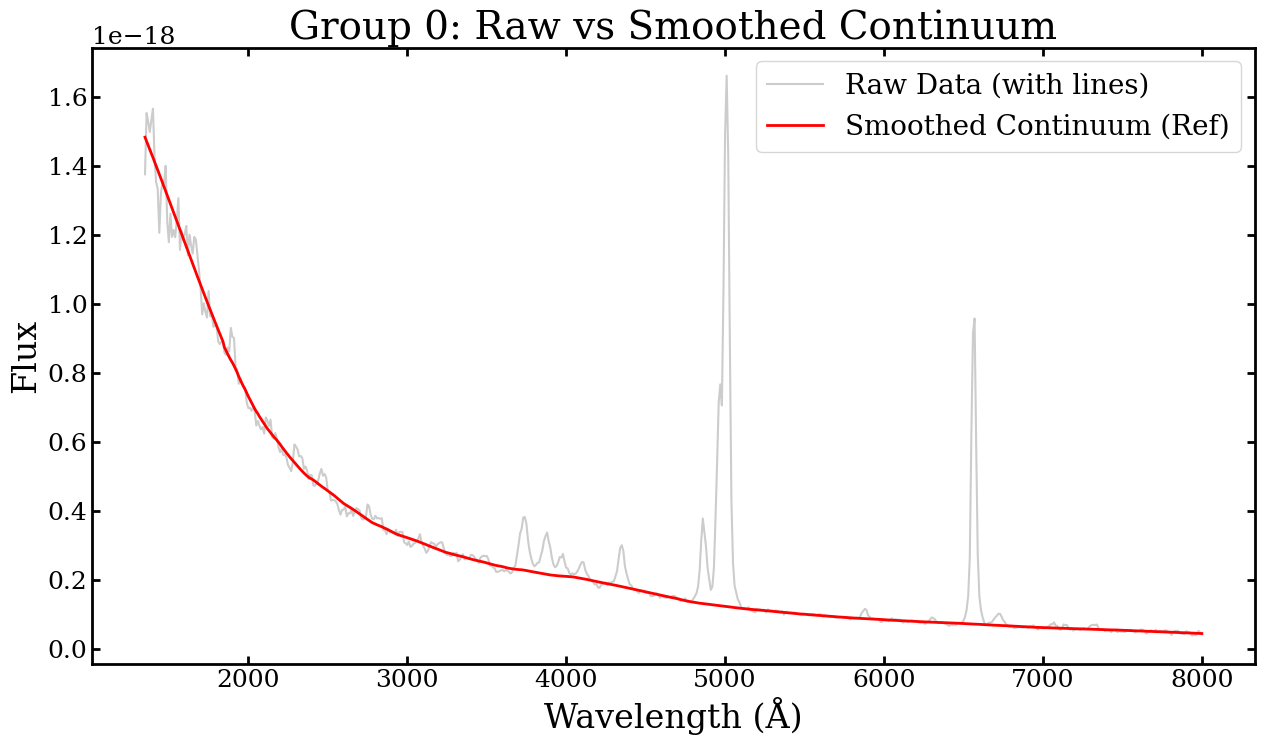

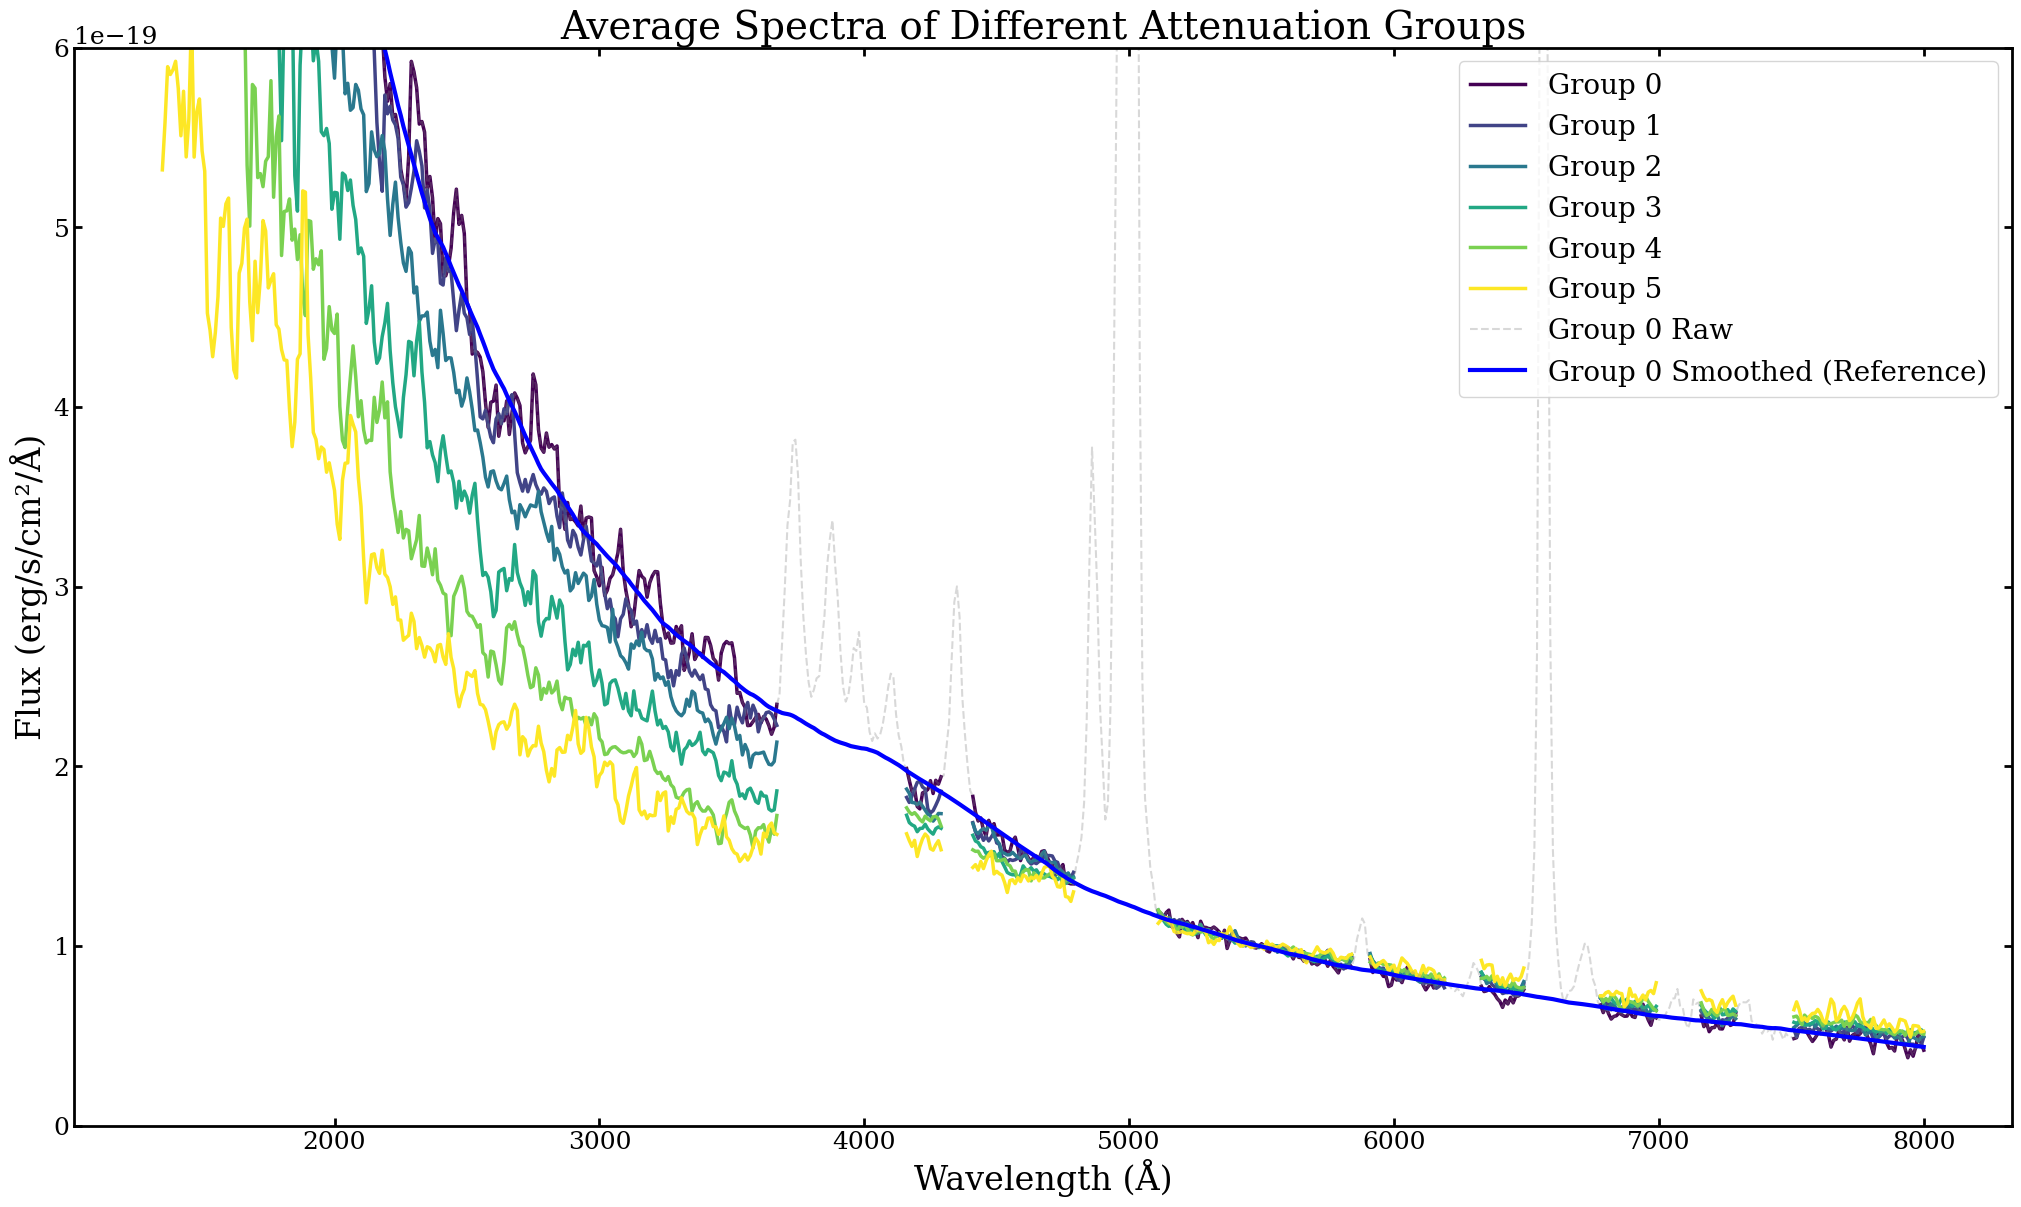

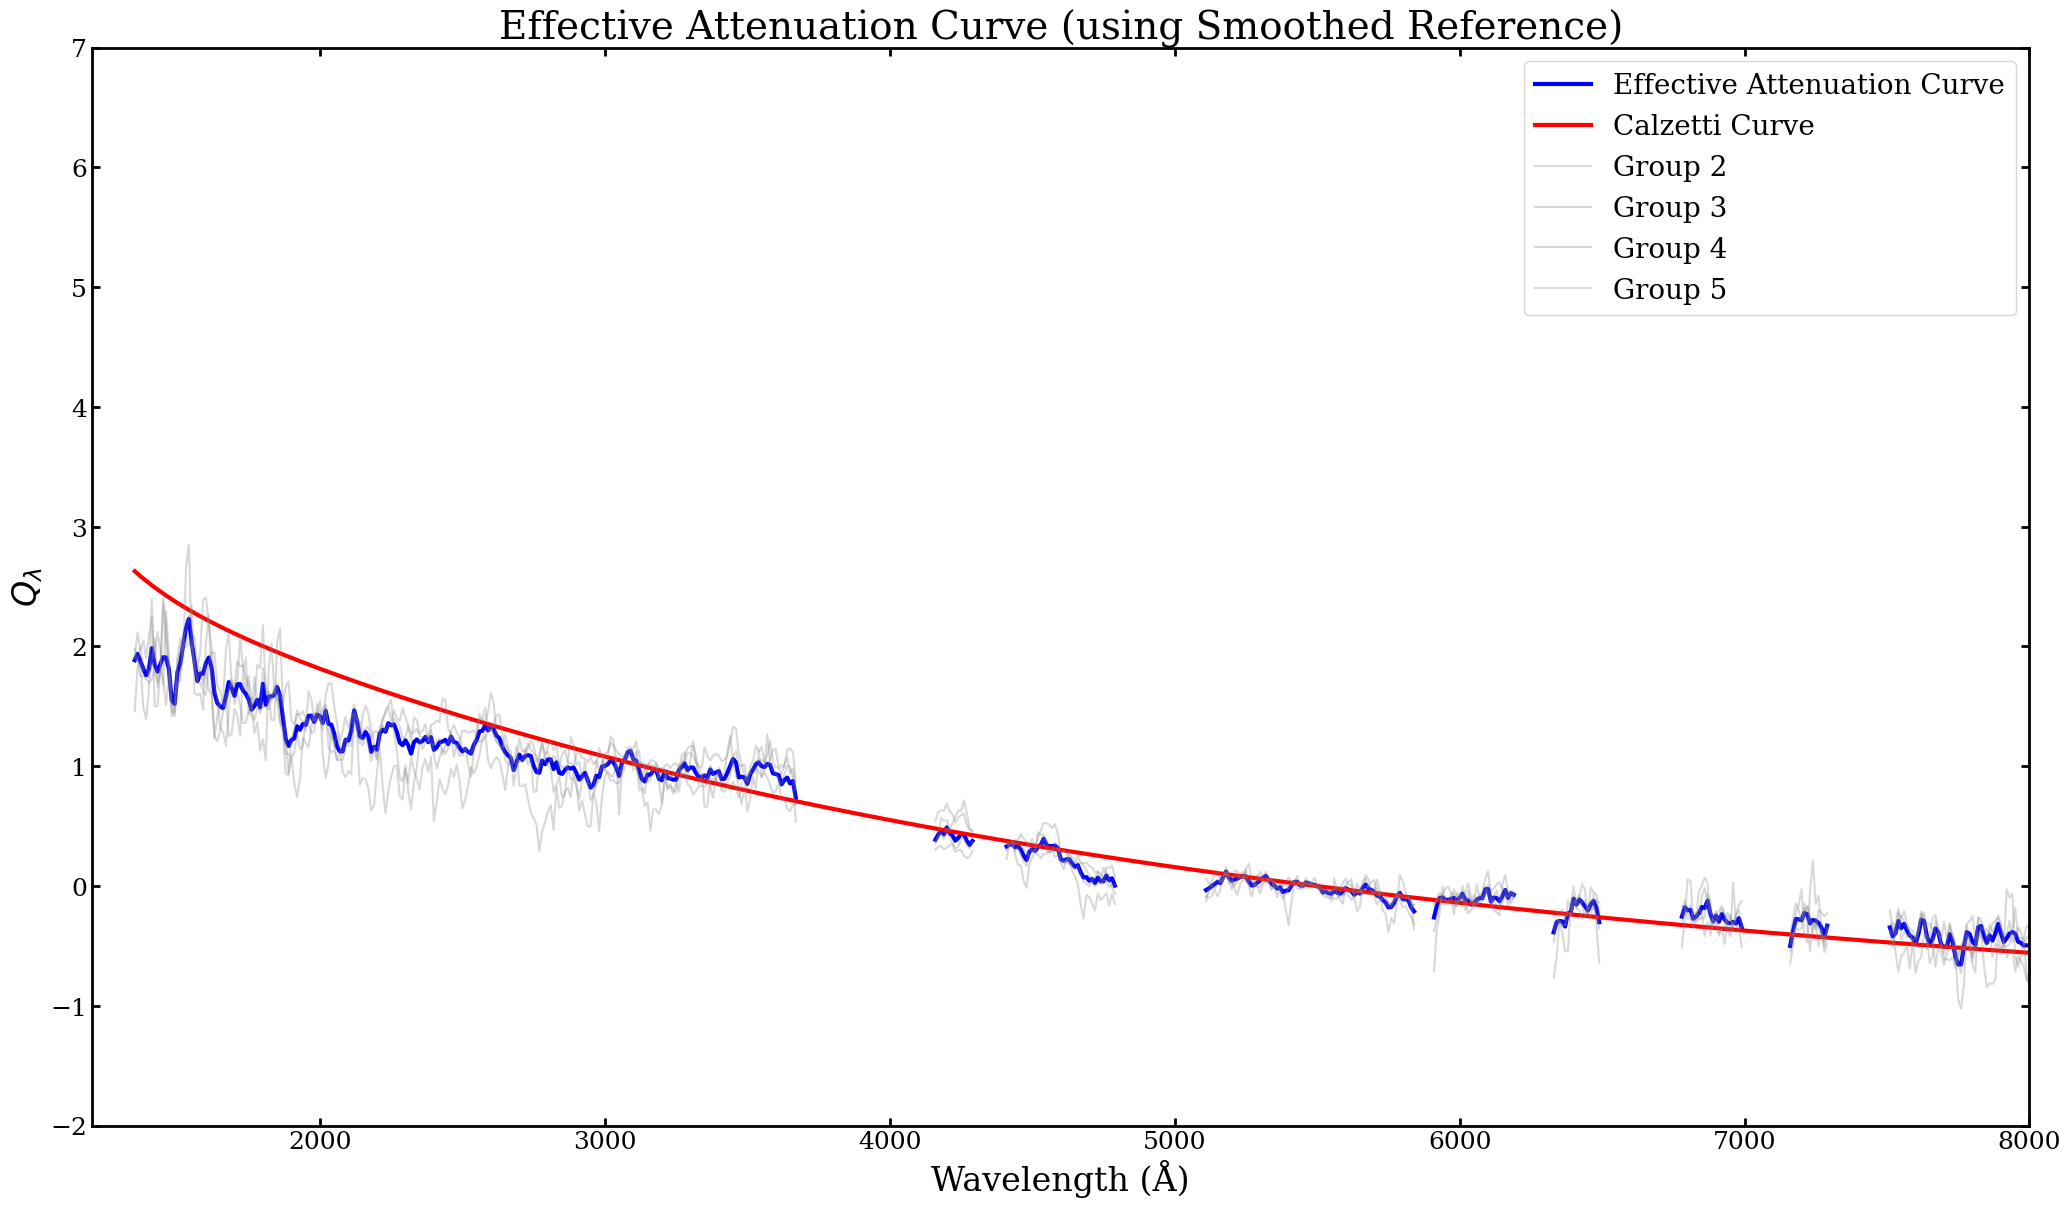

In [6]:
group_conditions = [(-0.05,0.02), (0.02,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.45),(0.45,0.6)]
def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return -1

from scipy.signal import savgol_filter
# ==========================================
# 1. 准备工作：分组与统计
# ==========================================

# 存储每组的 ID 列表
group_keys = defaultdict(list)
# 存储每组所有的 Balmer Decrement 值（用于计算组平均值）
group_decrement_values = defaultdict(list)

print("Categorizing catalog entries...")

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    # 基础过滤
    if not catalog['sample_flag']:
        continue

    try:
        # 获取参数
        line_params = catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']
        halpha_flux = line_params['halpha_flux']
        hbeta_flux = line_params['hbeta_flux']

        # 安全检查
        if hbeta_flux <= 0 or halpha_flux <= 0:
            continue

        # 计算单源的 Balmer Decrement
        bd_value = np.log(halpha_flux / hbeta_flux / 2.86)

        # 获取组号 (假设你有一个 group_condition_func 函数)
        group_index = group_condition_func(bd_value)

        if group_index != -1:
            group_keys[group_index].append(surveyid_subid)
            group_decrement_values[group_index].append(bd_value)

    except Exception as e:
        continue

# 计算每组的平均 Balmer Decrement
group_mean_decrement = {}
for idx, values in group_decrement_values.items():
    group_mean_decrement[idx] = np.mean(values)
    if idx==0:
        group_mean_decrement[idx]=0.0
    print(f"Group {idx}: {len(values)} spectra, Mean BD = {group_mean_decrement[idx]:.3f}")

# ==========================================
# 2. 批量处理光谱 (Averaging & Masking)
# ==========================================

# 定义发射线 Mask 区域
mask_regions = [
    (3675, 4150), (4300, 4400), (4800, 5100),
    (5850, 5900),(6200, 6325), (6500, 6775),
    (7000, 7150), (7300, 7500)
]

# 存储所有处理好的 Averager 对象
averagers = {}

# 按顺序处理存在的组
sorted_group_ids = sorted(group_keys.keys())

for group_idx in sorted_group_ids:
    keys = group_keys[group_idx]

    # 实例化
    # 注意：这里假设 FL.SpectrumAverager 是你最新的包含 apply_emission_line_mask 的类
    averager = FL.SpectrumAverager()

    # 加载 (需要传入你的读取函数 Load_Spectrum_From_Fits)
    success = averager.load_spectrum_catalog(keys, DJAv4Catalog, load_func=FL.Load_Spectrum_From_Fits)

    if not success:
        print(f"Group {group_idx} load failed.")
        continue

    # 处理流程
    averager.create_common_wavelength_grid(wavelength_range=(1350, 8000), grid_size=10)
    averager.interpolate_spectra(interpolation_method='linear')
    averager.spectrum_normalization_within_range(wavelength_range=(5400, 5600), target_flux=1.e-19)

    # 计算平均谱 (此时生成的是 Raw)
    averager.compute_average_spectrum(
        method='median',
        ignore_nan=True,
        use_percentile_filter=True,
        lower_percentile=16,
        upper_percentile=84
    )

    # 【关键步骤】应用 Mask
    averager.apply_emission_line_mask(mask_regions)

    # 存入字典
    averagers[group_idx] = averager
    print(f"Group {group_idx} processed successfully.")


ref_averager = averagers[0] # 假设你使用字典结构，或者使用 group0_averager

# 准备数据
wavelengths = ref_averager.common_wavelength # 单位 Angstrom
flux_raw = ref_averager.average_flux_raw   # 原始含发射线数据

# --- 参数设置 ---
# grid_size=10A, window_length=51 代表 510A 的平滑窗口，适合提取大尺度连续谱
# polyorder=3 适合保留一定的光谱特征（如 Balmer Break）
sg_window_length = 100
sg_polyorder = 3

# --- 步骤 A: 预处理 (Mask Emission Lines) ---
# 先复制一份数据，用于处理
flux_for_smoothing = flux_raw.copy()

# 将发射线区域设为 NaN (类似于你之前的 mask 逻辑，但在原数组上操作)
# 注意：这里直接使用 Angstrom，不需要除以 10000，保持单位统一
for (low, high) in mask_regions:
    mask_indices = (wavelengths >= low) & (wavelengths <= high)
    flux_for_smoothing[mask_indices] = np.nan

# --- 步骤 B: 插值填补 (Interpolation) ---
# 使用 Pandas 强大的插值功能填补 NaN，连接发射线两侧的连续谱
series_flux = pd.Series(flux_for_smoothing)
# limit_direction='both' 确保边缘也能被填补
flux_interpolated = series_flux.interpolate(method='linear', limit_direction='both').to_numpy()

# --- 步骤 C: SG 平滑 (Savitzky-Golay Filter) ---
# 现在 flux_interpolated 是连续的，没有 NaN，可以直接放入 sg_filter
flux_smoothed = savgol_filter(flux_interpolated, window_length=sg_window_length, polyorder=sg_polyorder)

# --- 步骤 D: 存储 ---
# 将平滑后的数据存回对象，方便后续调用
ref_averager.average_flux_smoothed = flux_smoothed

print("Group 0 spectrum smoothed and stored as 'average_flux_smoothed'.")

# --- 可视化检查 (这一步很重要，看看平滑是否过度或不足) ---
plt.figure(figsize=(15, 8))
plt.plot(wavelengths, flux_raw, color='gray', alpha=0.4, label='Raw Data (with lines)')
plt.plot(wavelengths, flux_smoothed, color='red', linewidth=2, label='Smoothed Continuum (Ref)')
plt.title('Group 0: Raw vs Smoothed Continuum')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.legend()
plt.show()


# ==========================================
# 3. 计算 Tau 和 Q 曲线
# ==========================================

if 0 not in averagers:
    raise ValueError("Group 0 (Reference Group) is missing! Cannot compute attenuation curves.")

# 获取基准数据 (Group 0)
# 使用 masked 数据，避免发射线影响比值
ref_flux = averagers[0].average_flux_masked
ref_decrement = group_mean_decrement[0]
curves_results = {}
ref_flux_smooth = averagers[0].average_flux_smoothed # 使用刚刚生成的平滑谱
ref_decrement = group_mean_decrement[0]

# 遍历计算
for i in sorted(averagers.keys()):
    if i == 0: continue

    target_averager = averagers[i]
    # 分子：使用 Mask 后的数据 (发射线处为 NaN)，这样结果图中发射线位置是断开的
    target_flux = target_averager.average_flux_masked
    target_decrement = group_mean_decrement[i]

    # 1. 计算 Tau (Optical Depth)
    # 分母由 smoothed 谱提供，它是连续且光滑的，不会引入额外的噪声
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = target_flux / ref_flux_smooth
        tau_lambda = -np.log(ratio)

    # 2. 计算 Q (Attenuation Curve)
    delta_bd = target_decrement - ref_decrement

    if delta_bd == 0:
        Q_lambda = np.full_like(tau_lambda, np.nan)
    else:
        Q_lambda = tau_lambda / delta_bd

    curves_results[i] = {
        'wavelength': target_averager.common_wavelength,
        'tau_lambda': tau_lambda, # 这里的 tau 在发射线处会是 NaN
        'Q_lambda': Q_lambda,
        'delta_bd': delta_bd
    }

# ==========================================
# 4. 可视化结果
# ==========================================

# 1. 画 Group 0 的对比 (Raw vs Smoothed)
# 为了不喧宾夺主，我们可以用虚线画 Raw，实线画 Smoothed
# 注意：这里 Q 曲线和 Flux 量级不同，不能画在一个轴上。
# 通常我们会把 Flux 画在一个子图，Q 曲线画在另一个子图。
# 但如果你想画在一起，我假设你是想画 Q 曲线结果：

# --- 下面是画 Q 曲线的代码 (Effective Curve) ---
# 如果你想画的是 Q 曲线，请忽略上面画 Flux 的两行，使用下面的逻辑：

# 计算 Effective Curve (加权平均)
target_groups = [2, 3, 4, 5] # 根据你的选择
q_list = [curves_results[g]['Q_lambda'] for g in target_groups if g in curves_results]
w_list = [curves_results[g]['delta_bd'] for g in target_groups if g in curves_results]


group_ids = sorted(averagers.keys())
num_groups = len(group_ids)

# 【修正点1】生成均匀分布的颜色 (0到1之间)
# 如果只有1组，避免 linspace 生成 [0]，强制使用 [0.5] 或其他
if num_groups > 1:
    colors = plt.cm.viridis(np.linspace(0, 1, num_groups))
else:
    colors = [plt.cm.viridis(0.5)]

fig, ax = plt.subplots(figsize=(25, 14))

for i, group_idx in enumerate(group_ids):
    averager = averagers[group_idx]

    # 【修正点2】优先绘制 Mask 后的连续谱
    # 如果该组应用了 apply_emission_line_mask，我们画 masked 数据
    if averager.average_flux_masked is not None:
        flux_to_plot = averager.average_flux_masked
    else:
        flux_to_plot = averager.average_flux

    # 绘制
    ax.plot(averager.common_wavelength, flux_to_plot,
            color=colors[i],
            linewidth=2.5, #稍微加粗一点
            label=f'Group {group_idx}')
ref_wave = averagers[0].common_wavelength
ax.plot(ref_wave, averagers[0].average_flux_raw, color='gray', alpha=0.3, linestyle='--', label='Group 0 Raw')
ax.plot(ref_wave, averagers[0].average_flux_smoothed, color='blue', linewidth=3, linestyle='-', label='Group 0 Smoothed (Reference)')

# --- 以下保留你的样式设置 ---

ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=24)
ax.legend(fontsize=20)


ax.set_title('Average Spectra of Different Attenuation Groups', fontsize=28)

# 根据实际归一化情况调整 Y 轴
# 如果你归一化到了 1e-19，这里范围可能需要微调
ax.set_ylim(0, 6e-19)
# ax.set_ylim(1e-20, 6e-19) # 你的原始设置

# 保存与显示
# plt.savefig('Average_Spectra_of_Different_Attenuation_Groups_Region.pdf', bbox_inches='tight', dpi=300)
plt.show()





fig, ax = plt.subplots(figsize=(25, 14))

if q_list:
    stack_q = np.ma.masked_invalid(np.array(q_list)) # 忽略 NaN
    effective_curve = np.ma.average(stack_q, axis=0, weights=w_list).filled(np.nan)

    # 画 Effective Curve
    ax.plot(ref_wave, effective_curve, color='blue', linewidth=3, label='Effective Attenuation Curve')

    # 画 Calzetti
    calz_curve = Calzetti(ref_wave/10000)
    ax.plot(ref_wave, calz_curve, color='red', linewidth=3, label='Calzetti Curve')

    # 画各个 Group 的 Q (作为背景)
    for g in target_groups:
        if g in curves_results:
            ax.plot(curves_results[g]['wavelength'], curves_results[g]['Q_lambda'],
                    color='gray', alpha=0.3, label=f'Group {g}')

# 设置
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel(r'$Q_\lambda$', fontsize=24) # 或者 Flux，看你想画哪个
ax.set_title('Effective Attenuation Curve (using Smoothed Reference)', fontsize=28)
ax.legend(fontsize=20)
ax.set_ylim(-2, 7) # 针对 Q 曲线的范围
ax.set_xlim(1200, 8000)

plt.show()

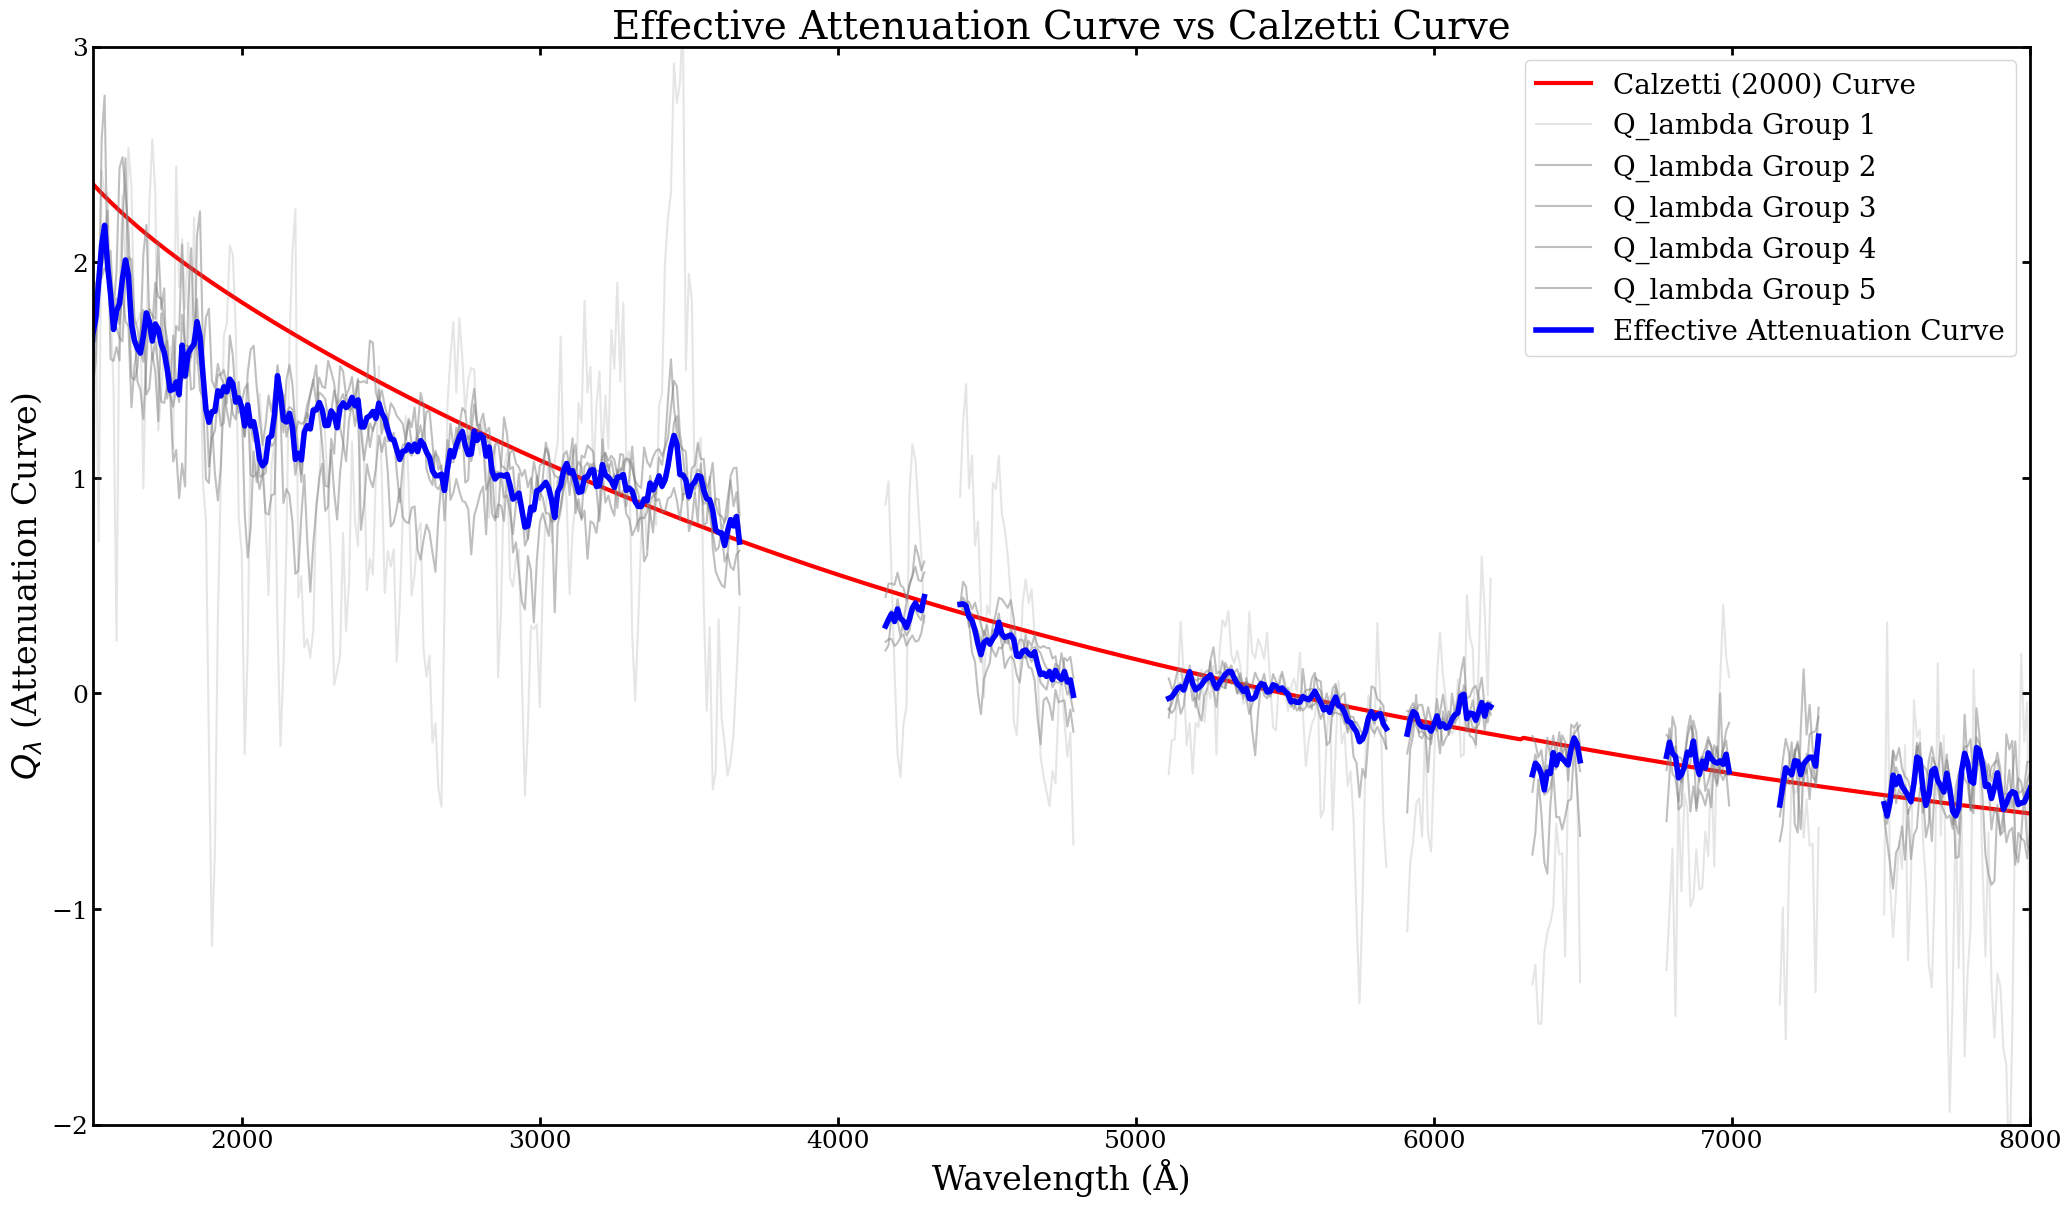

In [62]:
# ==========================================
# 1. 定义 Calzetti Law 函数
# ==========================================
def calzetti_law(wavelength_angstrom, Rv=4.05):
    """
    Returns k(lambda) for the Calzetti (2000) starburst attenuation curve.
    wavelength_angstrom: Wavelength in Angstroms
    """
    microns = wavelength_angstrom / 10000.0
    k_lambda = np.zeros_like(microns)

    # Range 1: 0.12 to 0.63 microns
    mask1 = (microns >= 0.12) & (microns < 0.63)
    w1 = microns[mask1]
    k_lambda[mask1] = (-2.156 + 1.509/w1 - 0.198/(w1**2) + 0.011/(w1**3))

    # Range 2: 0.63 to 2.20 microns
    mask2 = (microns >= 0.63) & (microns <= 2.20)
    w2 = microns[mask2]
    k_lambda[mask2] = (-1.857 + 1.040/w2)

    return k_lambda

# ==========================================
# 2. 准备数据 (从之前的 curves_results 提取)
# ==========================================

# 提取用于计算平均值的组 (假设排除 Group 1，从 Group 2 开始，根据你之前的切片逻辑 [1:])
# 注意：前提是 curves_results 包含 keys: 1, 2, 3, 4, 5...
target_groups_for_average = [2, 3, 4, 5]
q_arrays_for_avg = []
weights_for_avg = []

for gid in target_groups_for_average:
    if gid in curves_results:
        q_arrays_for_avg.append(curves_results[gid]['Q_lambda'])
        weights_for_avg.append(curves_results[gid]['delta_bd'])

# ==========================================
# 3. 计算加权平均 (处理 NaN)
# ==========================================

if len(q_arrays_for_avg) > 0:
    # 堆叠成二维数组 (Groups x Wavelength)
    stack_q = np.array(q_arrays_for_avg)

    # 使用 Masked Array 处理 NaN (发射线区域)
    # 这样平均时会自动忽略 NaN 的点
    masked_stack = np.ma.masked_invalid(stack_q)

    # 计算加权平均
    effective_attenuation_curve = np.ma.average(masked_stack, axis=0, weights=weights_for_avg)

    # 将 masked array 转回普通 numpy array (无效值填为 NaN)
    effective_attenuation_curve = effective_attenuation_curve.filled(np.nan)
else:
    print("Warning: No data available for averaging.")
    effective_attenuation_curve = None

# ==========================================
# 4. 绘图
# ==========================================

fig, ax = plt.subplots(figsize=(25, 14))

# A. 绘制 Calzetti Curve (红色)
# 获取通用波长 (从 Group 1 获取，假设所有组波长网格一致)
common_wave = averagers[1].common_wavelength
k_calzetti = calzetti_law(common_wave)
ax.plot(common_wave, k_calzetti, color='red', linewidth=3, label='Calzetti (2000) Curve')

# B. 绘制各个 Group 的 Q_lambda (灰色)
# 遍历 curves_results 中所有的结果
sorted_keys = sorted(curves_results.keys())
for i, gid in enumerate(sorted_keys):
    res = curves_results[gid]

    # Group 1 稍微透明一点，因为它没参与平均
    alpha = 0.2 if gid == 1 else 0.5
    label = f'Q_lambda Group {gid}'

    ax.plot(res['wavelength'], res['Q_lambda'], color='gray', alpha=alpha, label=label)

# C. 绘制 Effective Curve (蓝色)
if effective_attenuation_curve is not None:
    ax.plot(common_wave, effective_attenuation_curve, color='blue', linewidth=4, label='Effective Attenuation Curve')

# D. 样式设置 (保持你的原始风格)
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel(r'$Q_\lambda$ (Attenuation Curve)', fontsize=24)
ax.set_title('Effective Attenuation Curve vs Calzetti Curve', fontsize=28)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)
ax.xaxis.set_tick_params(which='minor', length=3)
ax.yaxis.set_tick_params(which='minor', length=3)

# 限制显示范围，聚焦重点区域
ax.set_xlim(1500, 8000)
ax.set_ylim(-2, 3) # Q曲线通常在 0 到 6 之间

plt.legend(fontsize=20)
plt.savefig('Effective_Attenuation_Curve_vs_Calzetti_Curve_Region.pdf', bbox_inches='tight', dpi=300)
plt.show()

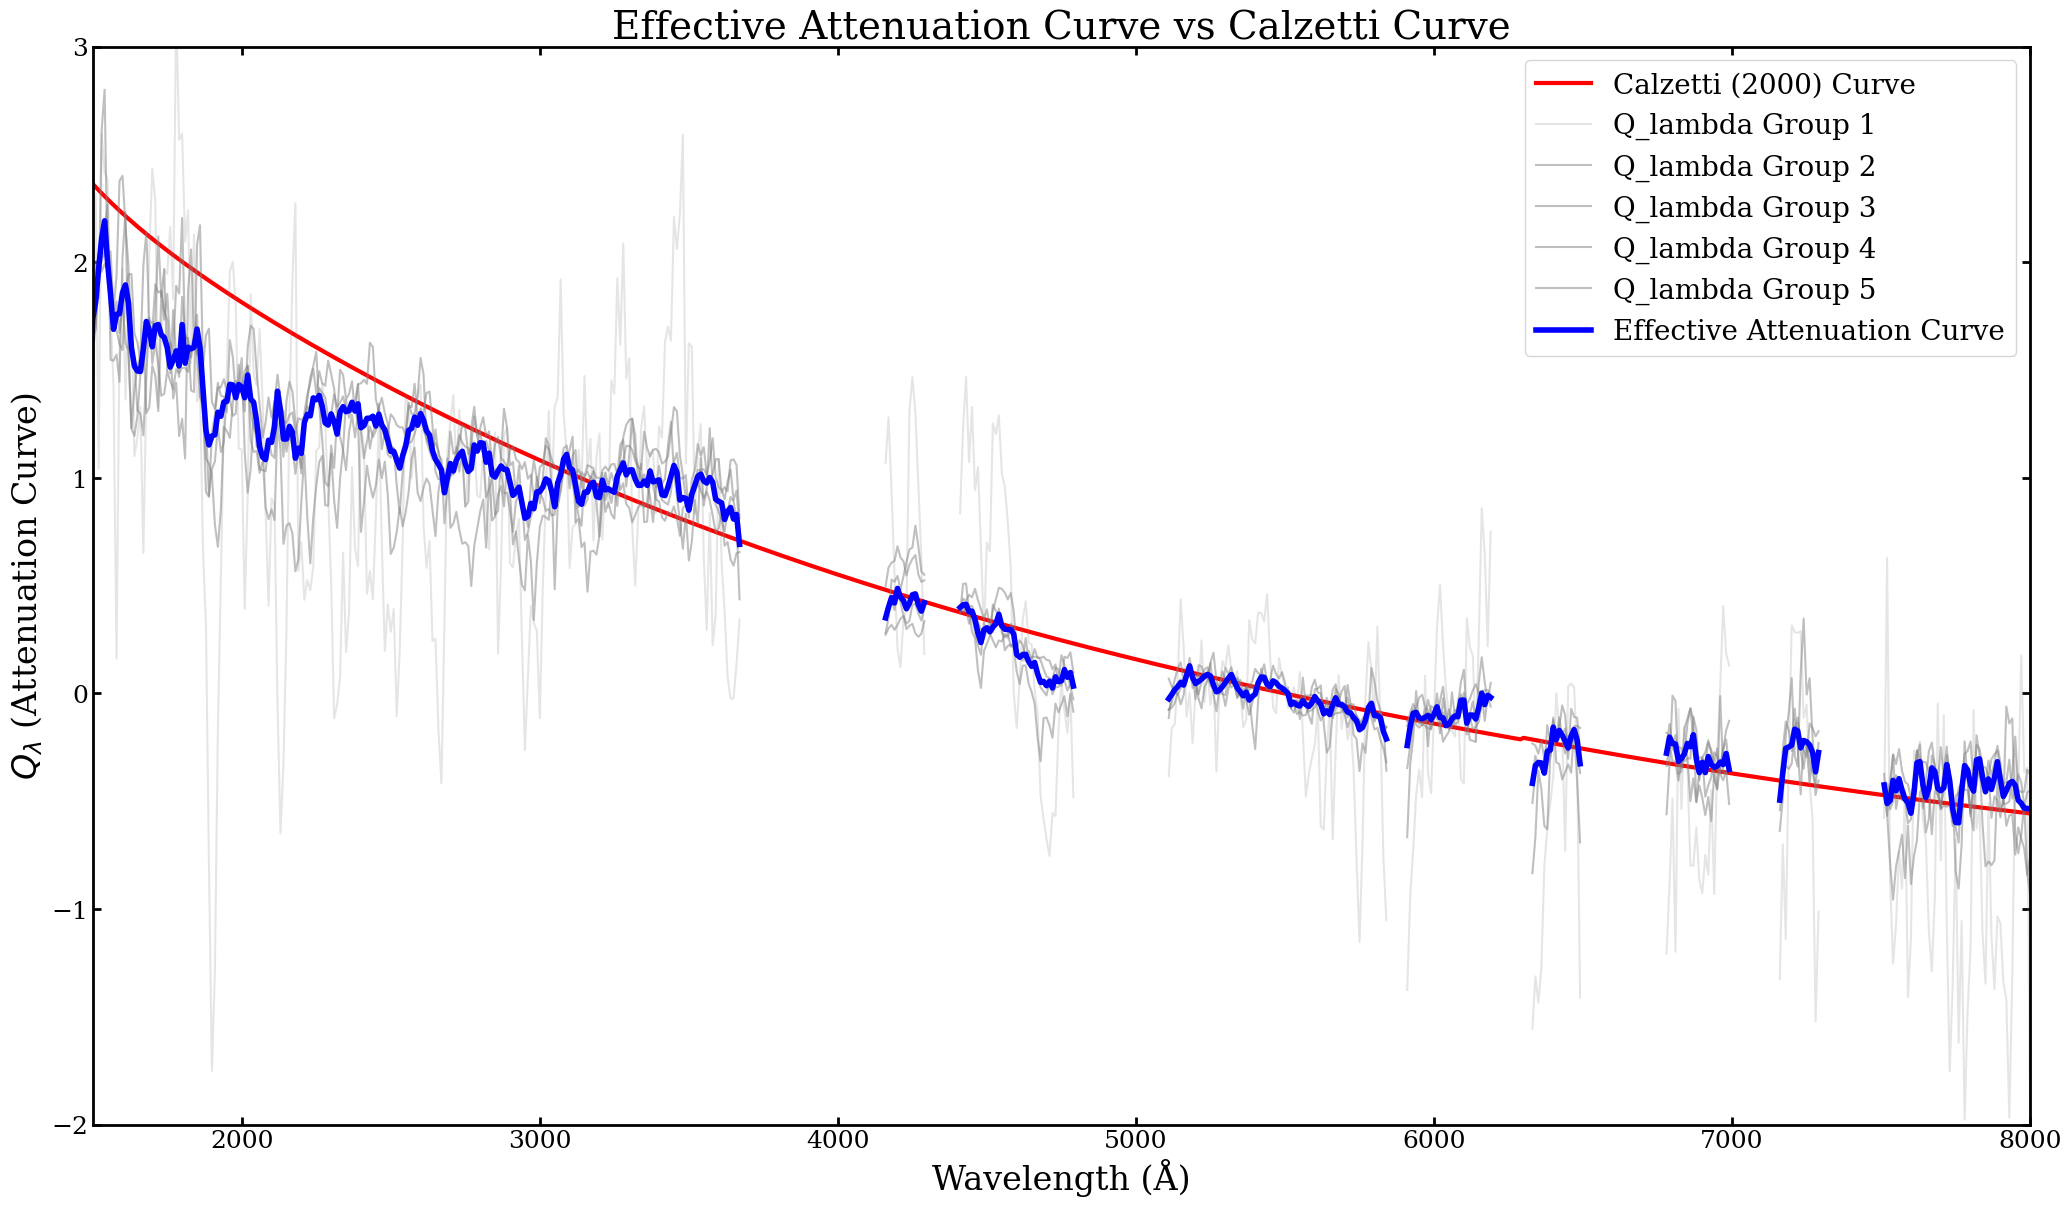

In [13]:
# ==========================================
# 1. 定义 Calzetti Law 函数
# ==========================================
def calzetti_law(wavelength_angstrom, Rv=4.05):
    """
    Returns k(lambda) for the Calzetti (2000) starburst attenuation curve.
    wavelength_angstrom: Wavelength in Angstroms
    """
    microns = wavelength_angstrom / 10000.0
    k_lambda = np.zeros_like(microns)

    # Range 1: 0.12 to 0.63 microns
    mask1 = (microns >= 0.12) & (microns < 0.63)
    w1 = microns[mask1]
    k_lambda[mask1] = (-2.156 + 1.509/w1 - 0.198/(w1**2) + 0.011/(w1**3))

    # Range 2: 0.63 to 2.20 microns
    mask2 = (microns >= 0.63) & (microns <= 2.20)
    w2 = microns[mask2]
    k_lambda[mask2] = (-1.857 + 1.040/w2)

    return k_lambda

# ==========================================
# 2. 准备数据 (从之前的 curves_results 提取)
# ==========================================

# 提取用于计算平均值的组 (假设排除 Group 1，从 Group 2 开始，根据你之前的切片逻辑 [1:])
# 注意：前提是 curves_results 包含 keys: 1, 2, 3, 4, 5...
target_groups_for_average = [2, 3, 4, 5]
q_arrays_for_avg = []
weights_for_avg = []

for gid in target_groups_for_average:
    if gid in curves_results:
        q_arrays_for_avg.append(curves_results[gid]['Q_lambda'])
        weights_for_avg.append(curves_results[gid]['delta_bd'])

# ==========================================
# 3. 计算加权平均 (处理 NaN)
# ==========================================

if len(q_arrays_for_avg) > 0:
    # 堆叠成二维数组 (Groups x Wavelength)
    stack_q = np.array(q_arrays_for_avg)

    # 使用 Masked Array 处理 NaN (发射线区域)
    # 这样平均时会自动忽略 NaN 的点
    masked_stack = np.ma.masked_invalid(stack_q)

    # 计算加权平均
    effective_attenuation_curve = np.ma.average(masked_stack, axis=0, weights=weights_for_avg)

    # 将 masked array 转回普通 numpy array (无效值填为 NaN)
    effective_attenuation_curve = effective_attenuation_curve.filled(np.nan)
else:
    print("Warning: No data available for averaging.")
    effective_attenuation_curve = None

# ==========================================
# 4. 绘图
# ==========================================

fig, ax = plt.subplots(figsize=(25, 14))

# A. 绘制 Calzetti Curve (红色)
# 获取通用波长 (从 Group 1 获取，假设所有组波长网格一致)
common_wave = averagers[1].common_wavelength
k_calzetti = calzetti_law(common_wave)
ax.plot(common_wave, k_calzetti, color='red', linewidth=3, label='Calzetti (2000) Curve')

# B. 绘制各个 Group 的 Q_lambda (灰色)
# 遍历 curves_results 中所有的结果
sorted_keys = sorted(curves_results.keys())
for i, gid in enumerate(sorted_keys):
    res = curves_results[gid]

    # Group 1 稍微透明一点，因为它没参与平均
    alpha = 0.2 if gid == 1 else 0.5
    label = f'Q_lambda Group {gid}'

    ax.plot(res['wavelength'], res['Q_lambda'], color='gray', alpha=alpha, label=label)

# C. 绘制 Effective Curve (蓝色)
if effective_attenuation_curve is not None:
    ax.plot(common_wave, effective_attenuation_curve, color='blue', linewidth=4, label='Effective Attenuation Curve')

# D. 样式设置 (保持你的原始风格)
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel(r'$Q_\lambda$ (Attenuation Curve)', fontsize=24)
ax.set_title('Effective Attenuation Curve vs Calzetti Curve', fontsize=28)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)
ax.xaxis.set_tick_params(which='minor', length=3)
ax.yaxis.set_tick_params(which='minor', length=3)

# 限制显示范围，聚焦重点区域
ax.set_xlim(1500, 8000)
ax.set_ylim(-2, 3) # Q曲线通常在 0 到 6 之间

plt.legend(fontsize=20)
plt.savefig('Effective_Attenuation_Curve_vs_Calzetti_Curve_Region.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [14]:

curves_results_nosmooth = {}

# 获取 Group 0 (Reference) 的未平滑 Mask 数据
# 注意：这里我们使用 masked 数据而不是 raw 数据，是为了防止发射线强度差异造成计算出的 Q 值在发射线处出现极端的尖峰。
# 使用 masked 数据意味着在发射线处，结果将是断开的 (NaN)。
ref_flux_nosmooth = averagers[0].average_flux_masked
ref_decrement = group_mean_decrement[0]

# ==========================================
# 循环计算 (Target Groups)
# ==========================================
# 假设我们要计算的组 (跳过 Group 0)
target_groups = sorted([g for g in averagers.keys() if g != 0])

for i in target_groups:
    target_averager = averagers[i]
    target_flux = target_averager.average_flux_masked
    target_decrement = group_mean_decrement[i]

    # 1. 计算 Tau (Optical Depth)
    # 使用 np.errstate 忽略除以 NaN 或 0 的警告
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = target_flux / ref_flux_nosmooth
        tau_lambda = -np.log(ratio)

    # 2. 计算 Q (Attenuation Curve)
    delta_bd = target_decrement - ref_decrement

    if delta_bd == 0:
        Q_lambda = np.full_like(tau_lambda, np.nan)
    else:
        Q_lambda = tau_lambda / delta_bd

    curves_results_nosmooth[i] = {
        'wavelength': target_averager.common_wavelength,
        'tau_lambda': tau_lambda,
        'Q_lambda': Q_lambda,
        'delta_bd': delta_bd
    }

print("Calculated Q curves using non-smoothed reference.")

# ==========================================
# 计算 Effective Attenuation Curve (无平滑版)
# ==========================================

# 定义用于合成 Effective Curve 的组 (例如 2, 3, 4, 5)
groups_for_avg = [2, 3, 4, 5]

q_arrays = []
weights = []

for gid in groups_for_avg:
    if gid in curves_results_nosmooth:
        q_arrays.append(curves_results_nosmooth[gid]['Q_lambda'])
        weights.append(curves_results_nosmooth[gid]['delta_bd'])

if q_arrays:
    # 堆叠数组
    stack_q = np.array(q_arrays)
    # 使用 Masked Array 处理 NaN (发射线区域被忽略)
    masked_stack = np.ma.masked_invalid(stack_q)
    # 计算加权平均
    effective_curve_nosmooth = np.ma.average(masked_stack, axis=0, weights=weights).filled(np.nan)
else:
    effective_curve_nosmooth = None

print("Calculated Effective Attenuation Curve (No Smoothing).")

Calculated Q curves using non-smoothed reference.
Calculated Effective Attenuation Curve (No Smoothing).


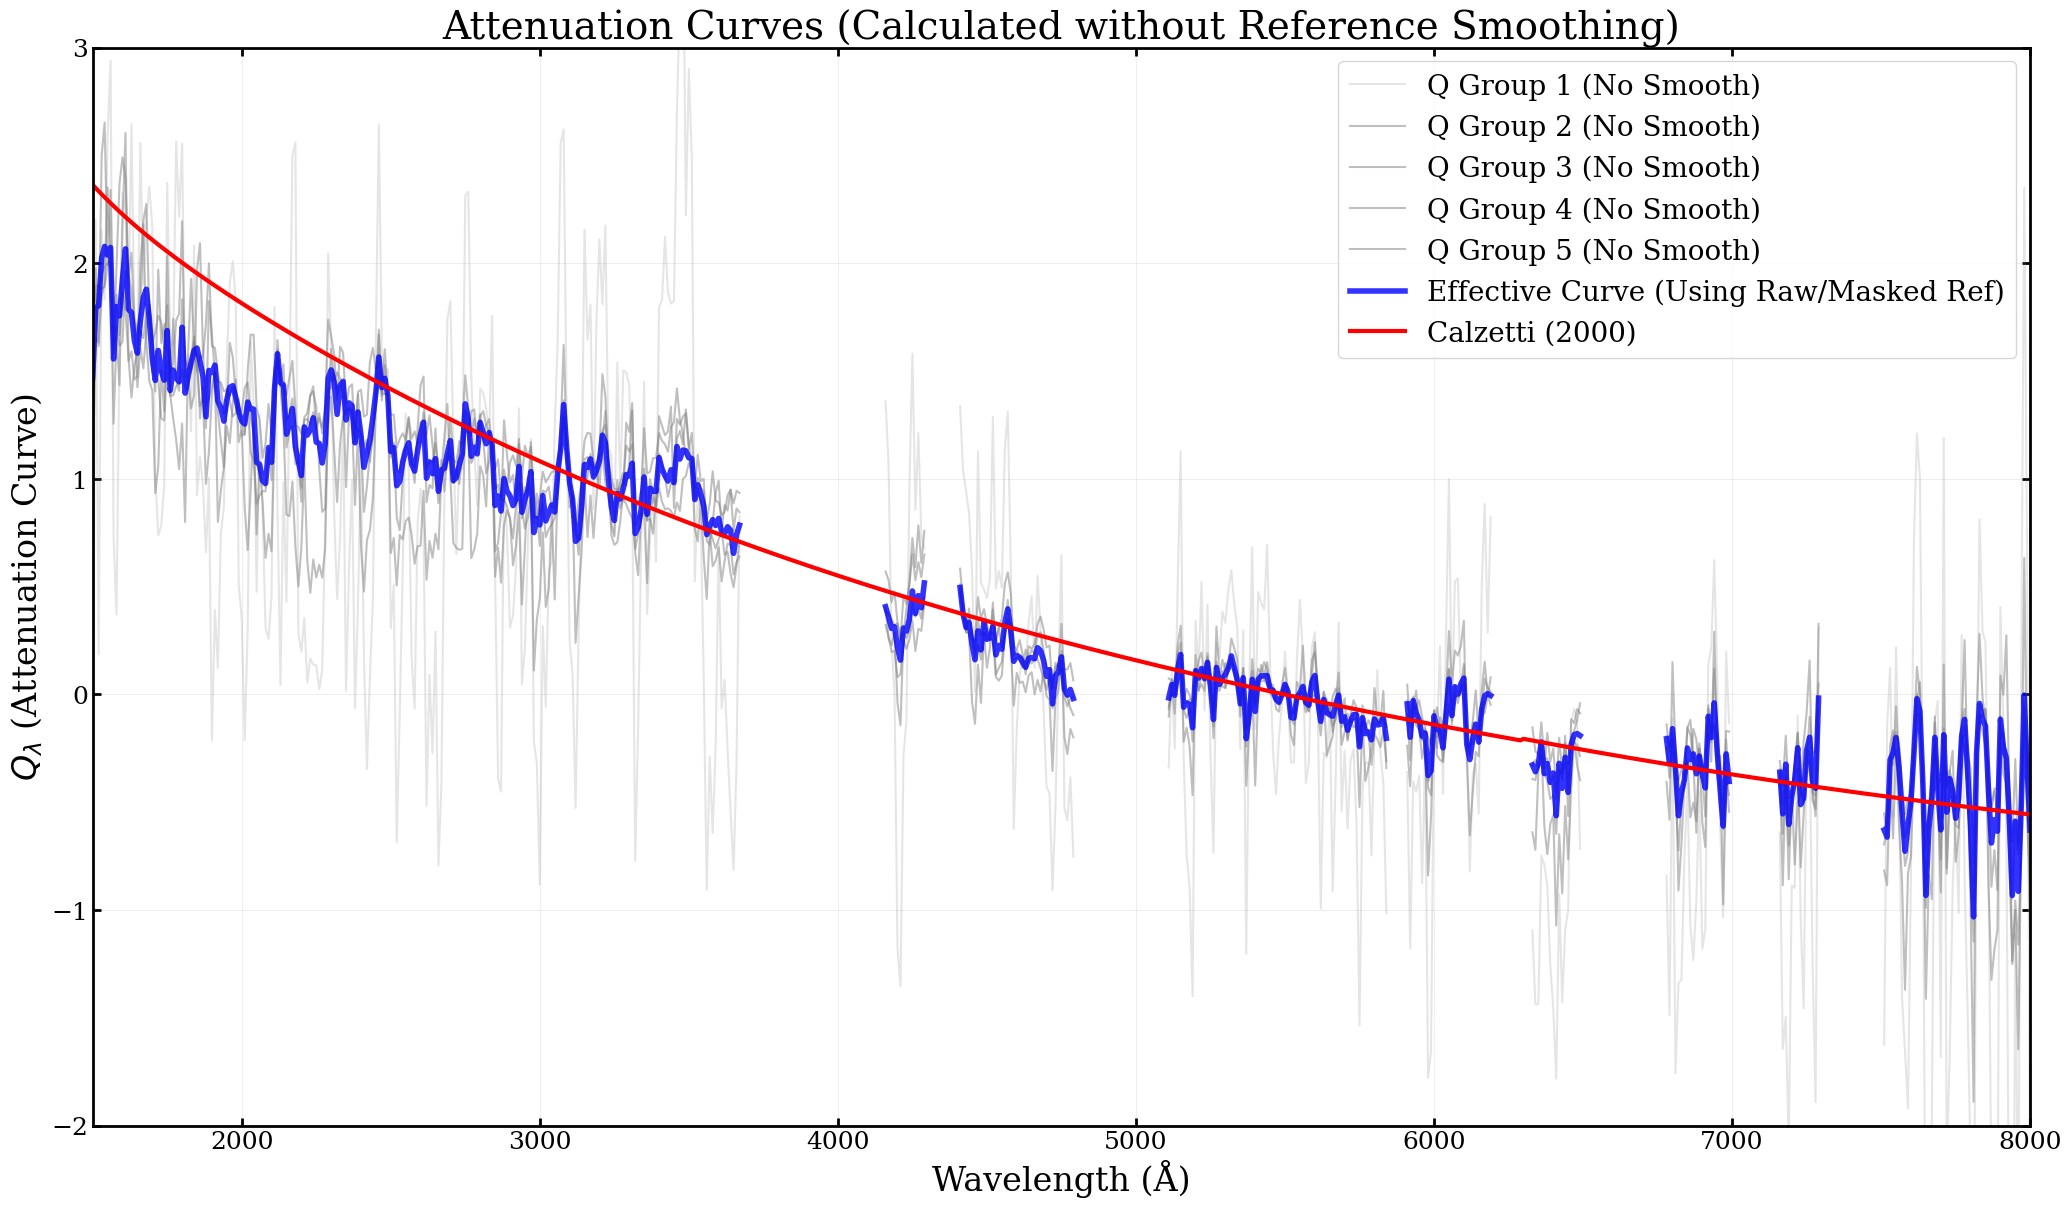

In [15]:

fig, ax = plt.subplots(figsize=(25, 14))

# 1. 绘制各个 Group 的 Q_lambda (无平滑) - 灰色背景
common_wave = averagers[0].common_wavelength

for i, gid in enumerate(sorted(curves_results_nosmooth.keys())):
    res = curves_results_nosmooth[gid]
    # 透明度设置：不参与合成的组淡一点
    alpha = 0.5 if gid in groups_for_avg else 0.2
    ax.plot(res['wavelength'], res['Q_lambda'],
            color='gray', alpha=alpha, label=f'Q Group {gid} (No Smooth)')

# 2. 绘制 Effective Attenuation Curve (无平滑) - 蓝色细线
if effective_curve_nosmooth is not None:
    ax.plot(common_wave, effective_curve_nosmooth,
            color='blue', linewidth=4, alpha=0.8,
            label='Effective Curve (Using Raw/Masked Ref)')

# 3. 绘制 Calzetti Curve - 红色实线
k_calzetti = calzetti_law(common_wave)
ax.plot(common_wave, k_calzetti, color='red', linewidth=3, label='Calzetti (2000)')

# --- 样式设置 ---
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel(r'$Q_\lambda$ (Attenuation Curve)', fontsize=24)
ax.set_title('Attenuation Curves (Calculated without Reference Smoothing)', fontsize=28)

ax.set_xlim(1500, 8000)
ax.set_ylim(-2, 3)
plt.legend(fontsize=20)
plt.grid(True, alpha=0.2)

# plt.savefig('Attenuation_Curve_No_Smoothing.pdf', bbox_inches='tight')
plt.show()

Fitted Polynomial on x = 1/λ (μm^-1):
Q(x) = (0.0182)x³ + (-0.2939)x² + (1.7583)x + (-2.2986)


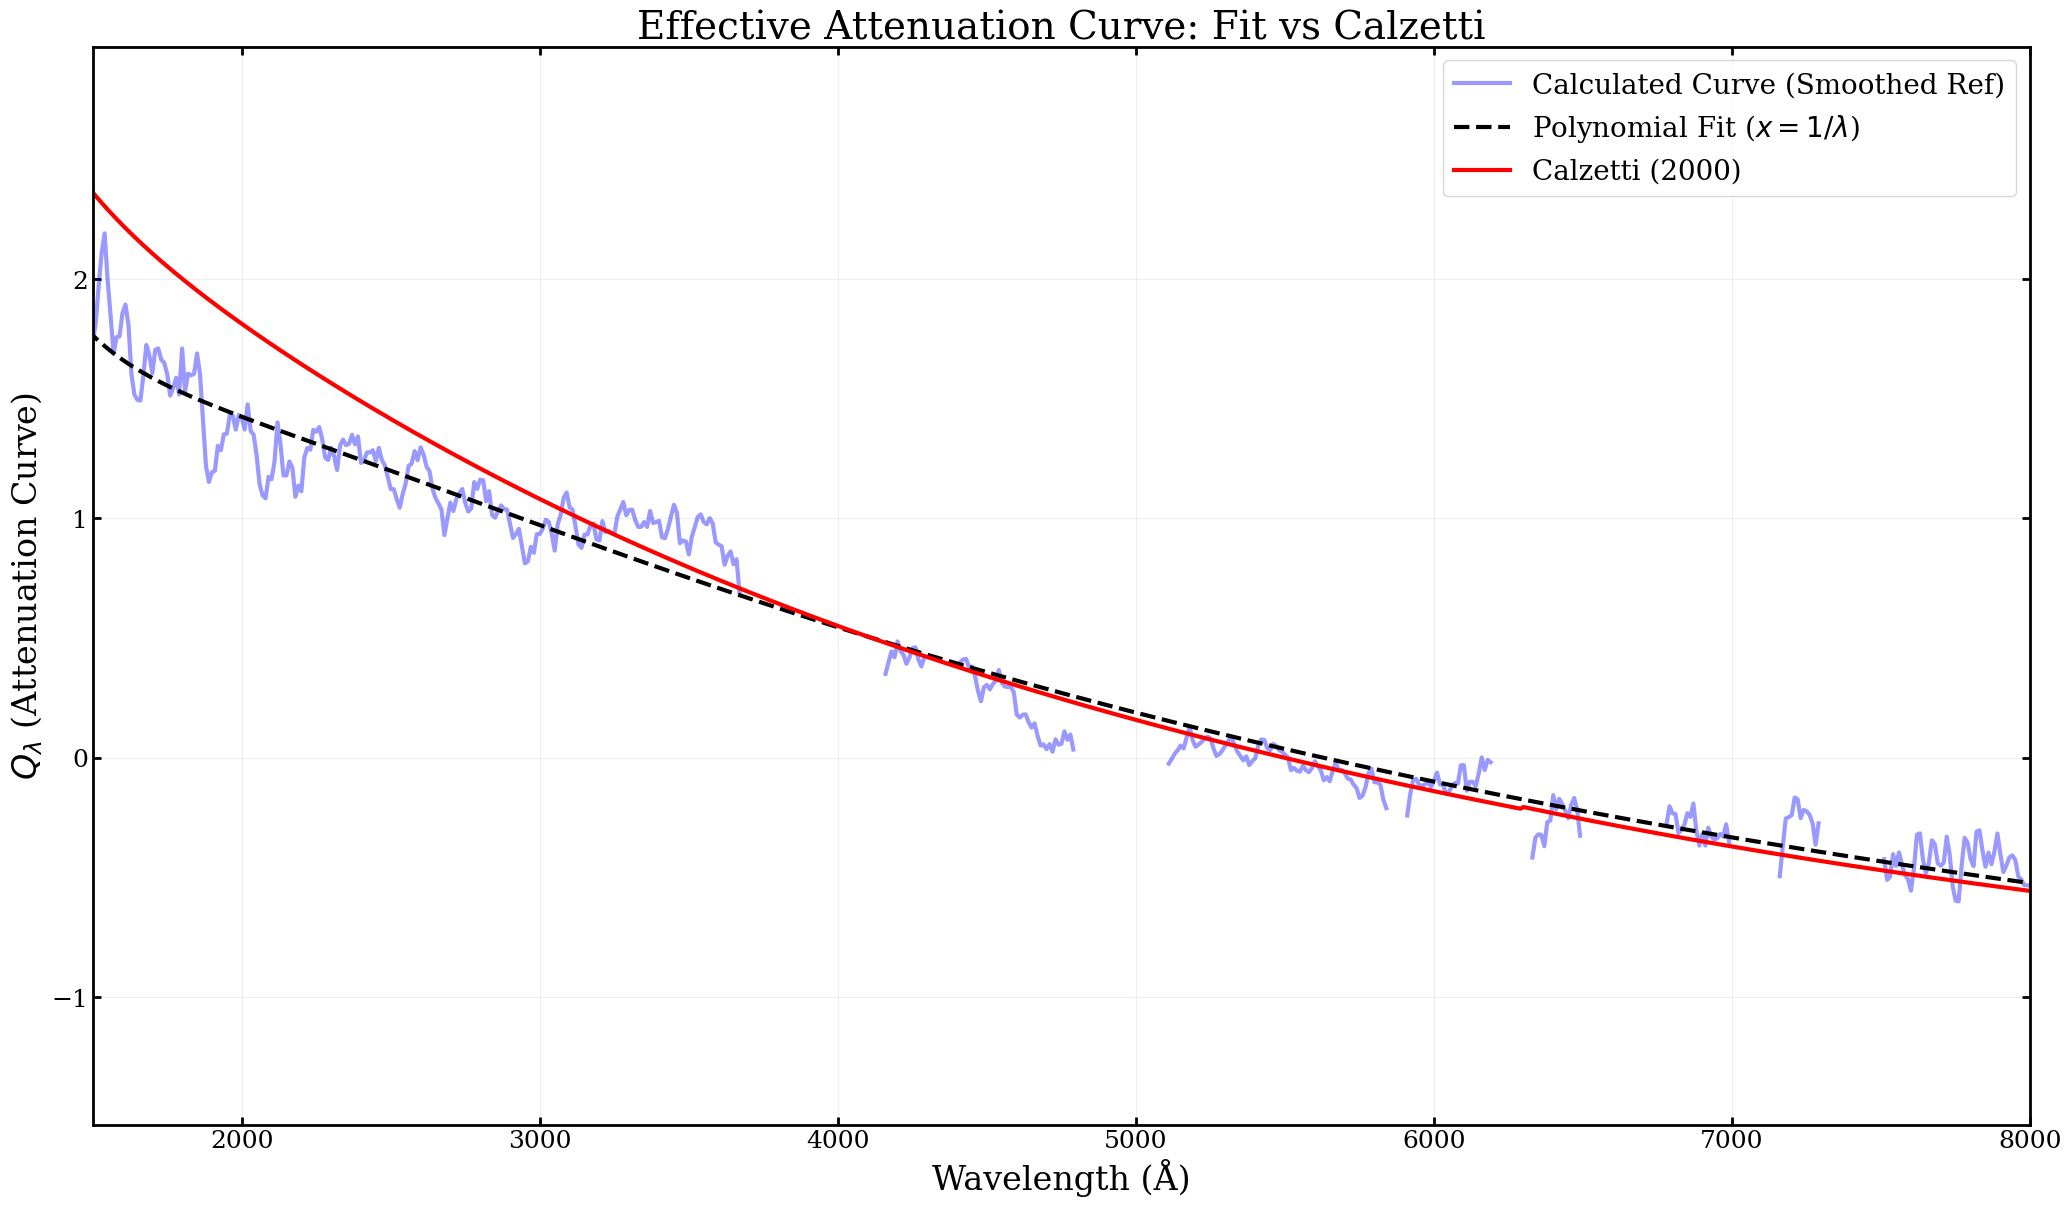

In [16]:

# ==========================================

# 假设变量名是 effective_attenuation_curve (基于 smoothed reference 计算的)
y_data = effective_attenuation_curve
wave_ang = averagers[0].common_wavelength

# 【关键步骤】转换为 inverse microns (1/μm)
# 1 μm = 10000 Å
wave_microns = wave_ang / 10000.0
x_inverse_microns = 1.0 / wave_microns  # 这就是 x

# 剔除 NaN (发射线区域) 以便拟合
valid_mask = np.isfinite(y_data) & np.isfinite(x_inverse_microns)

x_fit = x_inverse_microns[valid_mask]
y_fit = y_data[valid_mask]

# ==========================================
# 2. 对 1/lambda 进行三次多项式拟合
# ==========================================

# 拟合公式: Q(x) = c0*x^3 + c1*x^2 + c2*x + c3
# 其中 x = 1/lambda (μm^-1)
coeffs = np.polyfit(x_fit, y_fit, 3)
poly_func = np.poly1d(coeffs)

# 生成拟合曲线 (应用到所有波长点)
y_poly_fitted = poly_func(x_inverse_microns)

# 打印拟合参数
print("Fitted Polynomial on x = 1/λ (μm^-1):")
print(f"Q(x) = ({coeffs[0]:.4f})x³ + ({coeffs[1]:.4f})x² + ({coeffs[2]:.4f})x + ({coeffs[3]:.4f})")

# ==========================================
# 3. 绘图 (X轴保持为波长，方便观察)
# ==========================================

fig, ax = plt.subplots(figsize=(25, 14))

# A. 原始计算数据 (Effective Curve) - 蓝色半透明
# 这样能看到原始数据里的噪声和被 Mask 掉的空隙
ax.plot(wave_ang, y_data, color='blue', linewidth=3, alpha=0.4, label='Calculated Curve (Smoothed Ref)')

# B. 多项式拟合结果 - 黑色虚线
# 虽然是对 1/lambda 拟合的，但画图时 x 轴用波长，这样符合直觉
ax.plot(wave_ang, y_poly_fitted, color='black', linewidth=3, linestyle='--', label=r'Polynomial Fit ($x=1/\lambda$)')

# C. Calzetti Curve - 红色实线
calz_curve = calzetti_law(wave_ang)
ax.plot(wave_ang, calz_curve, color='red', linewidth=3, label='Calzetti (2000)')

# --- 样式美化 ---
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel(r'$Q_\lambda$ (Attenuation Curve)', fontsize=24)
ax.set_title(r'Effective Attenuation Curve: Fit vs Calzetti', fontsize=28)

# 坐标轴与边框
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')

ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)
ax.xaxis.set_tick_params(which='minor', length=3)
ax.yaxis.set_tick_params(which='minor', length=3)

# 范围设置
ax.set_xlim(1500, 8000)
# 动态调整Y轴范围，避免极端值
valid_y = y_data[np.isfinite(y_data)]
if len(valid_y) > 0:
    ax.set_ylim(np.percentile(valid_y, 1) - 1, np.percentile(valid_y, 99) + 1)
else:
    ax.set_ylim(-2, 7)

plt.legend(fontsize=20)
plt.grid(True, alpha=0.2)

# plt.savefig('Attenuation_Curve_Fit_InverseLambda.pdf', bbox_inches='tight', dpi=300)
plt.show()

Derived Rv (Value at 5500A) = 6.488


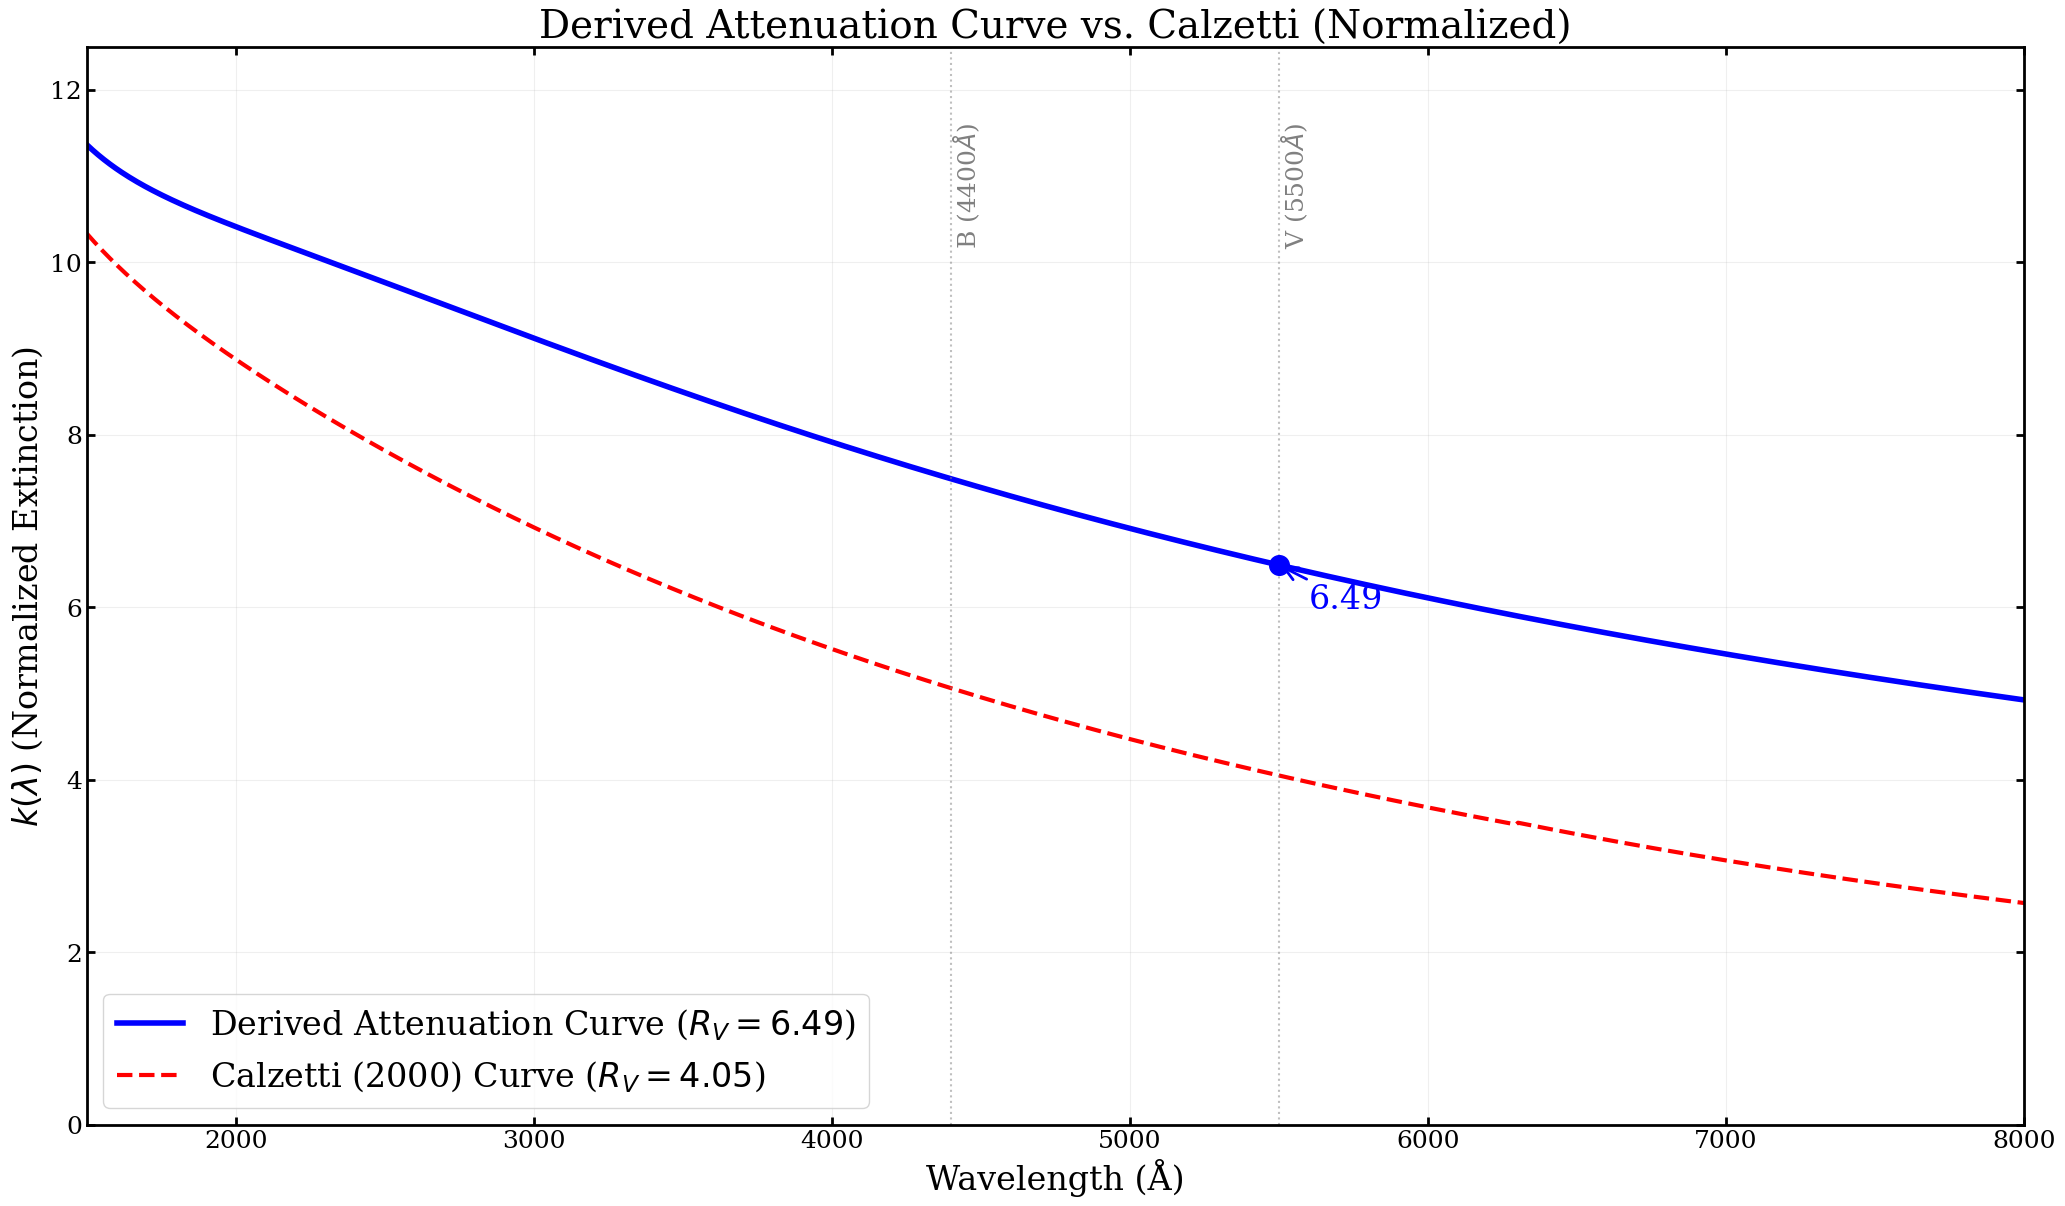

Final Equation: k(x) = S * (c3*x^3 + c2*x^2 + c1*x)
Where x = 1/λ (μm^-1)
Scaling Factor S = 2.7883
Coefficients from fit: c3=0.0178, c2=-0.2886, c1=1.7458


In [75]:
# 定义基础形状函数 (强制过原点 -> 移除常数项 c0)
# P_raw(x) = c3*x^3 + c2*x^2 + c1*x
def poly_shape_raw(x_inverse_microns):
    c3, c2, c1 = coeffs[0], coeffs[1], coeffs[2] # 忽略 coeffs[3] (常数项)
    return c3 * x_inverse_microns**3 + c2 * x_inverse_microns**2 + c1 * x_inverse_microns

# 计算归一化因子
# 目标: k(4400) - k(5500) = 1
# 4400A = 0.44um -> x = 1/0.44
# 5500A = 0.55um -> x = 1/0.55

x_B = 1.0 / 0.44
x_V = 1.0 / 0.55

val_B_raw = poly_shape_raw(x_B)
val_V_raw = poly_shape_raw(x_V)

# 计算缩放因子 S
# S * (val_B - val_V) = 1  =>  S = 1 / (val_B - val_V)
scaling_factor = 1.0 / (val_B_raw - val_V_raw)

# 定义最终的曲线方程 k(lambda)
def derived_k_curve(wavelength_angstrom):
    w_microns = wavelength_angstrom / 10000.0
    x = 1.0 / w_microns
    return scaling_factor * poly_shape_raw(x)

# ==========================================
# 2. 计算数据用于绘图
# ==========================================

# 定义绘图的波长网格
plot_wave = np.linspace(1500, 8000, 1000)

# 计算你的曲线
my_k_curve = derived_k_curve(plot_wave)

# 计算 Calzetti 曲线 (使用 Rv=4.05 标准值)
calz_k_curve = 2.659*calzetti_law(plot_wave, Rv=4.05)+4.05

# 计算 5500A 处的数值 (即你的 Rv)
my_Rv = derived_k_curve(5500)
print(f"Derived Rv (Value at 5500A) = {my_Rv:.3f}")

# ==========================================
# 3. 绘图
# ==========================================

fig, ax = plt.subplots(figsize=(25, 14))

# 绘制你的曲线
ax.plot(plot_wave, my_k_curve, color='blue', linewidth=4, label=f'Derived Attenuation Curve ($R_V={my_Rv:.2f}$)')

# 绘制 Calzetti 曲线
ax.plot(plot_wave, calz_k_curve, color='red', linewidth=3, linestyle='--', label='Calzetti (2000) Curve ($R_V=4.05$)')

# 标注 5500A 处的点
ax.scatter([5500], [my_Rv], color='blue', s=200, zorder=10)
ax.annotate(f'{my_Rv:.2f}', xy=(5500, my_Rv), xytext=(5600, my_Rv - 0.5),
            fontsize=24, color='blue', arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# 辅助线: 标示出 5500A 和 4400A 的位置，展示归一化
ax.axvline(5500, color='gray', linestyle=':', alpha=0.5)
ax.axvline(4400, color='gray', linestyle=':', alpha=0.5)
ax.text(4400, max(my_k_curve)*0.9, 'B (4400$\AA$)', fontsize=18, rotation=90, color='gray')
ax.text(5500, max(my_k_curve)*0.9, 'V (5500$\AA$)', fontsize=18, rotation=90, color='gray')

# --- 样式美化 ---
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel(r'$k(\lambda)$ (Normalized Extinction)', fontsize=24)
ax.set_title('Derived Attenuation Curve vs. Calzetti (Normalized)', fontsize=28)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')

ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)

ax.set_xlim(1500, 8000)
# 自动调整Y轴
ax.set_ylim(0, max(np.max(my_k_curve), np.max(calz_k_curve)) * 1.1)

plt.legend(fontsize=24)
plt.grid(True, alpha=0.2)

plt.savefig('Derived_k_Curve_vs_Calzetti.pdf', bbox_inches='tight', dpi=300)
plt.show()

# 打印最终方程参数
print("="*30)
print("Final Equation: k(x) = S * (c3*x^3 + c2*x^2 + c1*x)")
print(f"Where x = 1/λ (μm^-1)")
print(f"Scaling Factor S = {scaling_factor:.4f}")
print(f"Coefficients from fit: c3={coeffs[0]:.4f}, c2={coeffs[1]:.4f}, c1={coeffs[2]:.4f}")

Derived Rv (Value at 5500A) = 6.537


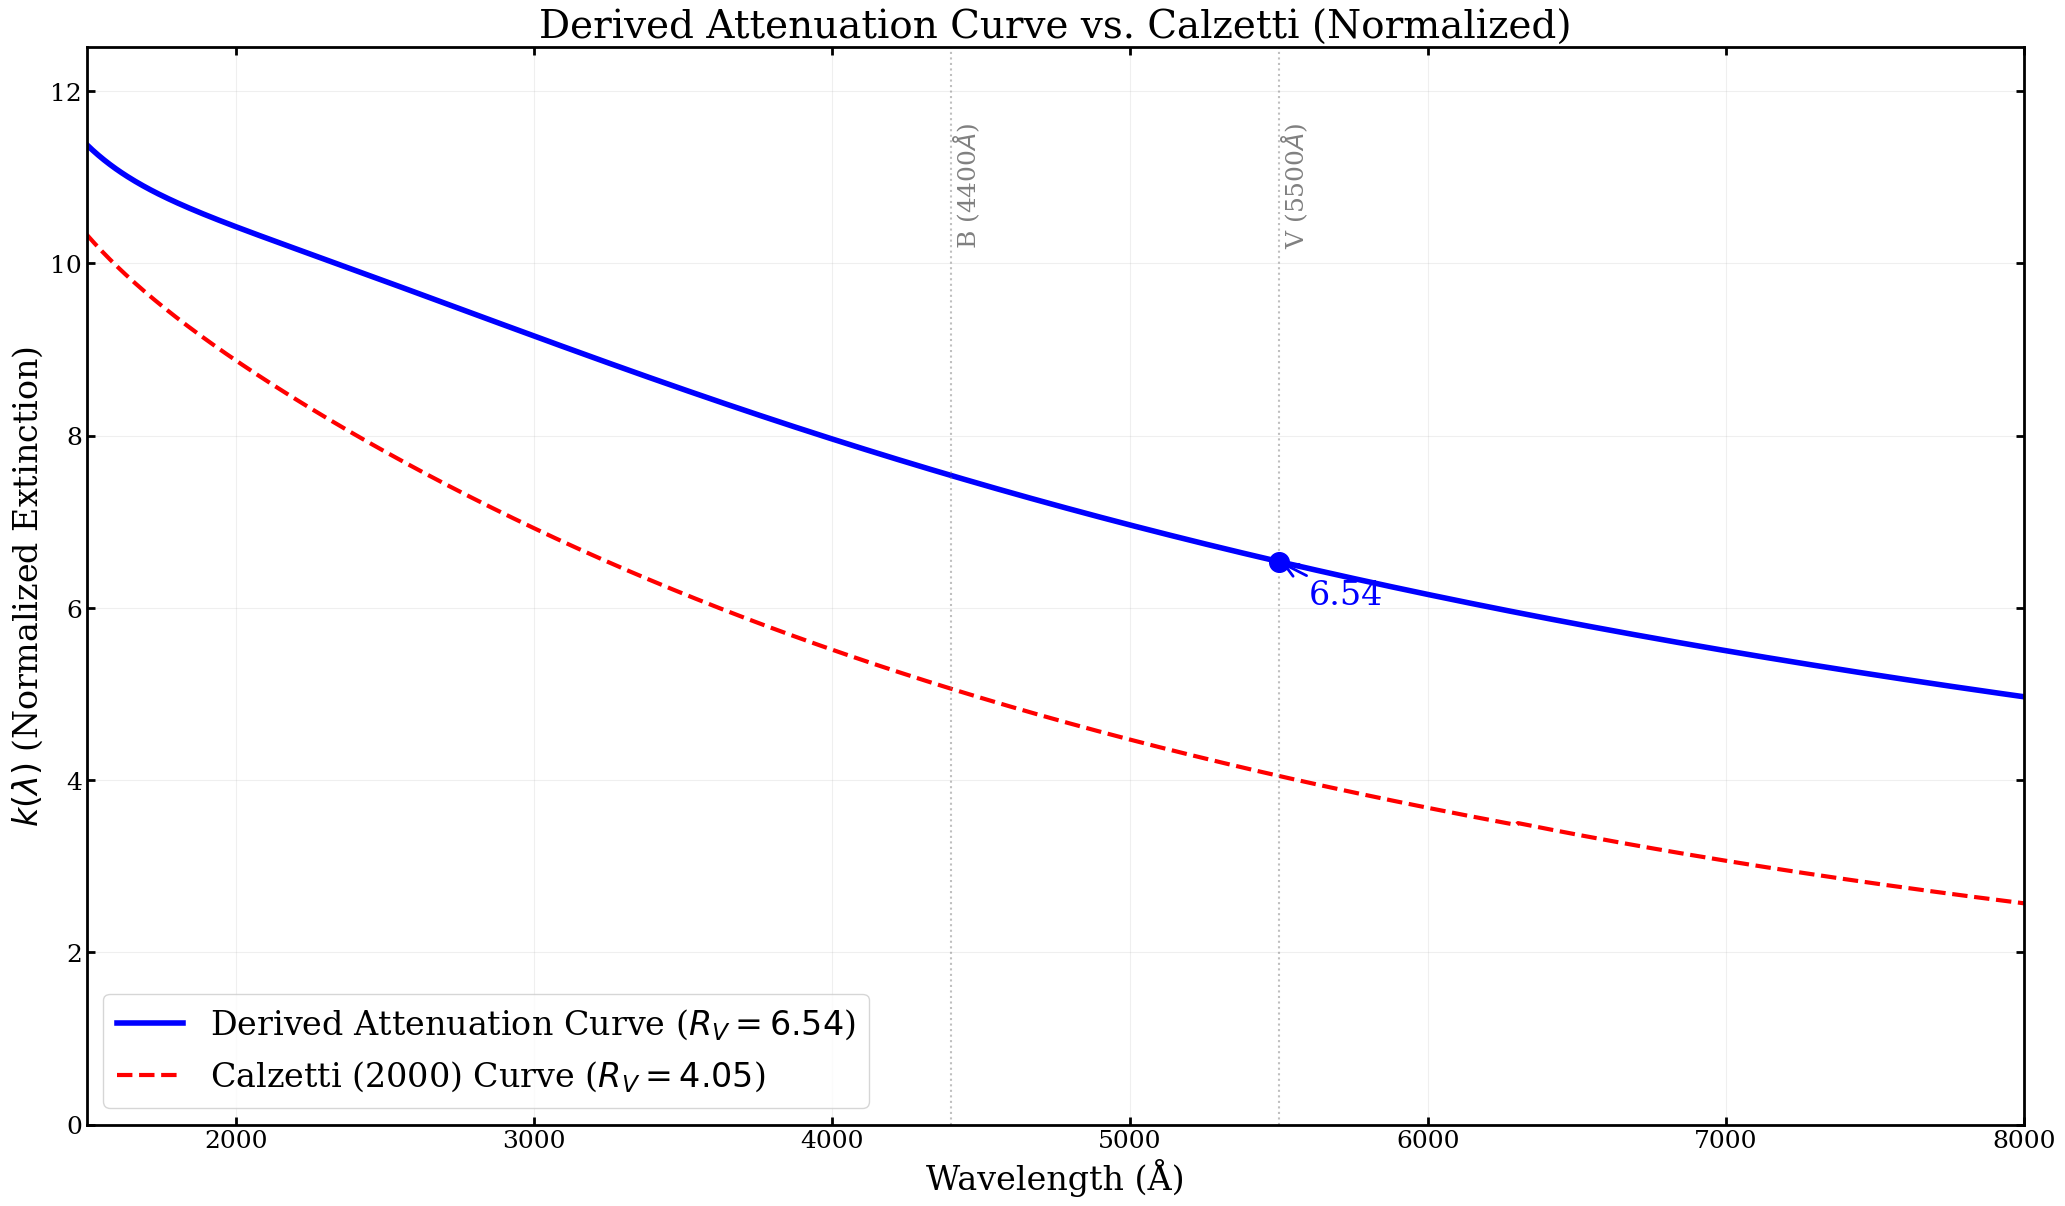

Final Equation: k(x) = S * (c3*x^3 + c2*x^2 + c1*x)
Where x = 1/λ (μm^-1)
Scaling Factor S = 2.7995
Coefficients from fit: c3=0.0182, c2=-0.2939, c1=1.7583


In [17]:
# 定义基础形状函数 (强制过原点 -> 移除常数项 c0)
# P_raw(x) = c3*x^3 + c2*x^2 + c1*x
def poly_shape_raw(x_inverse_microns):
    c3, c2, c1 = coeffs[0], coeffs[1], coeffs[2] # 忽略 coeffs[3] (常数项)
    return c3 * x_inverse_microns**3 + c2 * x_inverse_microns**2 + c1 * x_inverse_microns

# 计算归一化因子
# 目标: k(4400) - k(5500) = 1
# 4400A = 0.44um -> x = 1/0.44
# 5500A = 0.55um -> x = 1/0.55

x_B = 1.0 / 0.44
x_V = 1.0 / 0.55

val_B_raw = poly_shape_raw(x_B)
val_V_raw = poly_shape_raw(x_V)

# 计算缩放因子 S
# S * (val_B - val_V) = 1  =>  S = 1 / (val_B - val_V)
scaling_factor = 1.0 / (val_B_raw - val_V_raw)

# 定义最终的曲线方程 k(lambda)
def derived_k_curve(wavelength_angstrom):
    w_microns = wavelength_angstrom / 10000.0
    x = 1.0 / w_microns
    return scaling_factor * poly_shape_raw(x)

# ==========================================
# 2. 计算数据用于绘图
# ==========================================

# 定义绘图的波长网格
plot_wave = np.linspace(1500, 8000, 1000)

# 计算你的曲线
my_k_curve = derived_k_curve(plot_wave)

# 计算 Calzetti 曲线 (使用 Rv=4.05 标准值)
calz_k_curve = 2.659*calzetti_law(plot_wave, Rv=4.05)+4.05

# 计算 5500A 处的数值 (即你的 Rv)
my_Rv = derived_k_curve(5500)
print(f"Derived Rv (Value at 5500A) = {my_Rv:.3f}")

# ==========================================
# 3. 绘图
# ==========================================

fig, ax = plt.subplots(figsize=(25, 14))

# 绘制你的曲线
ax.plot(plot_wave, my_k_curve, color='blue', linewidth=4, label=f'Derived Attenuation Curve ($R_V={my_Rv:.2f}$)')

# 绘制 Calzetti 曲线
ax.plot(plot_wave, calz_k_curve, color='red', linewidth=3, linestyle='--', label='Calzetti (2000) Curve ($R_V=4.05$)')

# 标注 5500A 处的点
ax.scatter([5500], [my_Rv], color='blue', s=200, zorder=10)
ax.annotate(f'{my_Rv:.2f}', xy=(5500, my_Rv), xytext=(5600, my_Rv - 0.5),
            fontsize=24, color='blue', arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# 辅助线: 标示出 5500A 和 4400A 的位置，展示归一化
ax.axvline(5500, color='gray', linestyle=':', alpha=0.5)
ax.axvline(4400, color='gray', linestyle=':', alpha=0.5)
ax.text(4400, max(my_k_curve)*0.9, 'B (4400$\AA$)', fontsize=18, rotation=90, color='gray')
ax.text(5500, max(my_k_curve)*0.9, 'V (5500$\AA$)', fontsize=18, rotation=90, color='gray')

# --- 样式美化 ---
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel(r'$k(\lambda)$ (Normalized Extinction)', fontsize=24)
ax.set_title('Derived Attenuation Curve vs. Calzetti (Normalized)', fontsize=28)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')

ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)

ax.set_xlim(1500, 8000)
# 自动调整Y轴
ax.set_ylim(0, max(np.max(my_k_curve), np.max(calz_k_curve)) * 1.1)

plt.legend(fontsize=24)
plt.grid(True, alpha=0.2)

plt.savefig('Derived_k_Curve_vs_Calzetti.pdf', bbox_inches='tight', dpi=300)
plt.show()

# 打印最终方程参数
print("="*30)
print("Final Equation: k(x) = S * (c3*x^3 + c2*x^2 + c1*x)")
print(f"Where x = 1/λ (μm^-1)")
print(f"Scaling Factor S = {scaling_factor:.4f}")
print(f"Coefficients from fit: c3={coeffs[0]:.4f}, c2={coeffs[1]:.4f}, c1={coeffs[2]:.4f}")

New Derived Rv (with intercept -0.89877) = 5.638


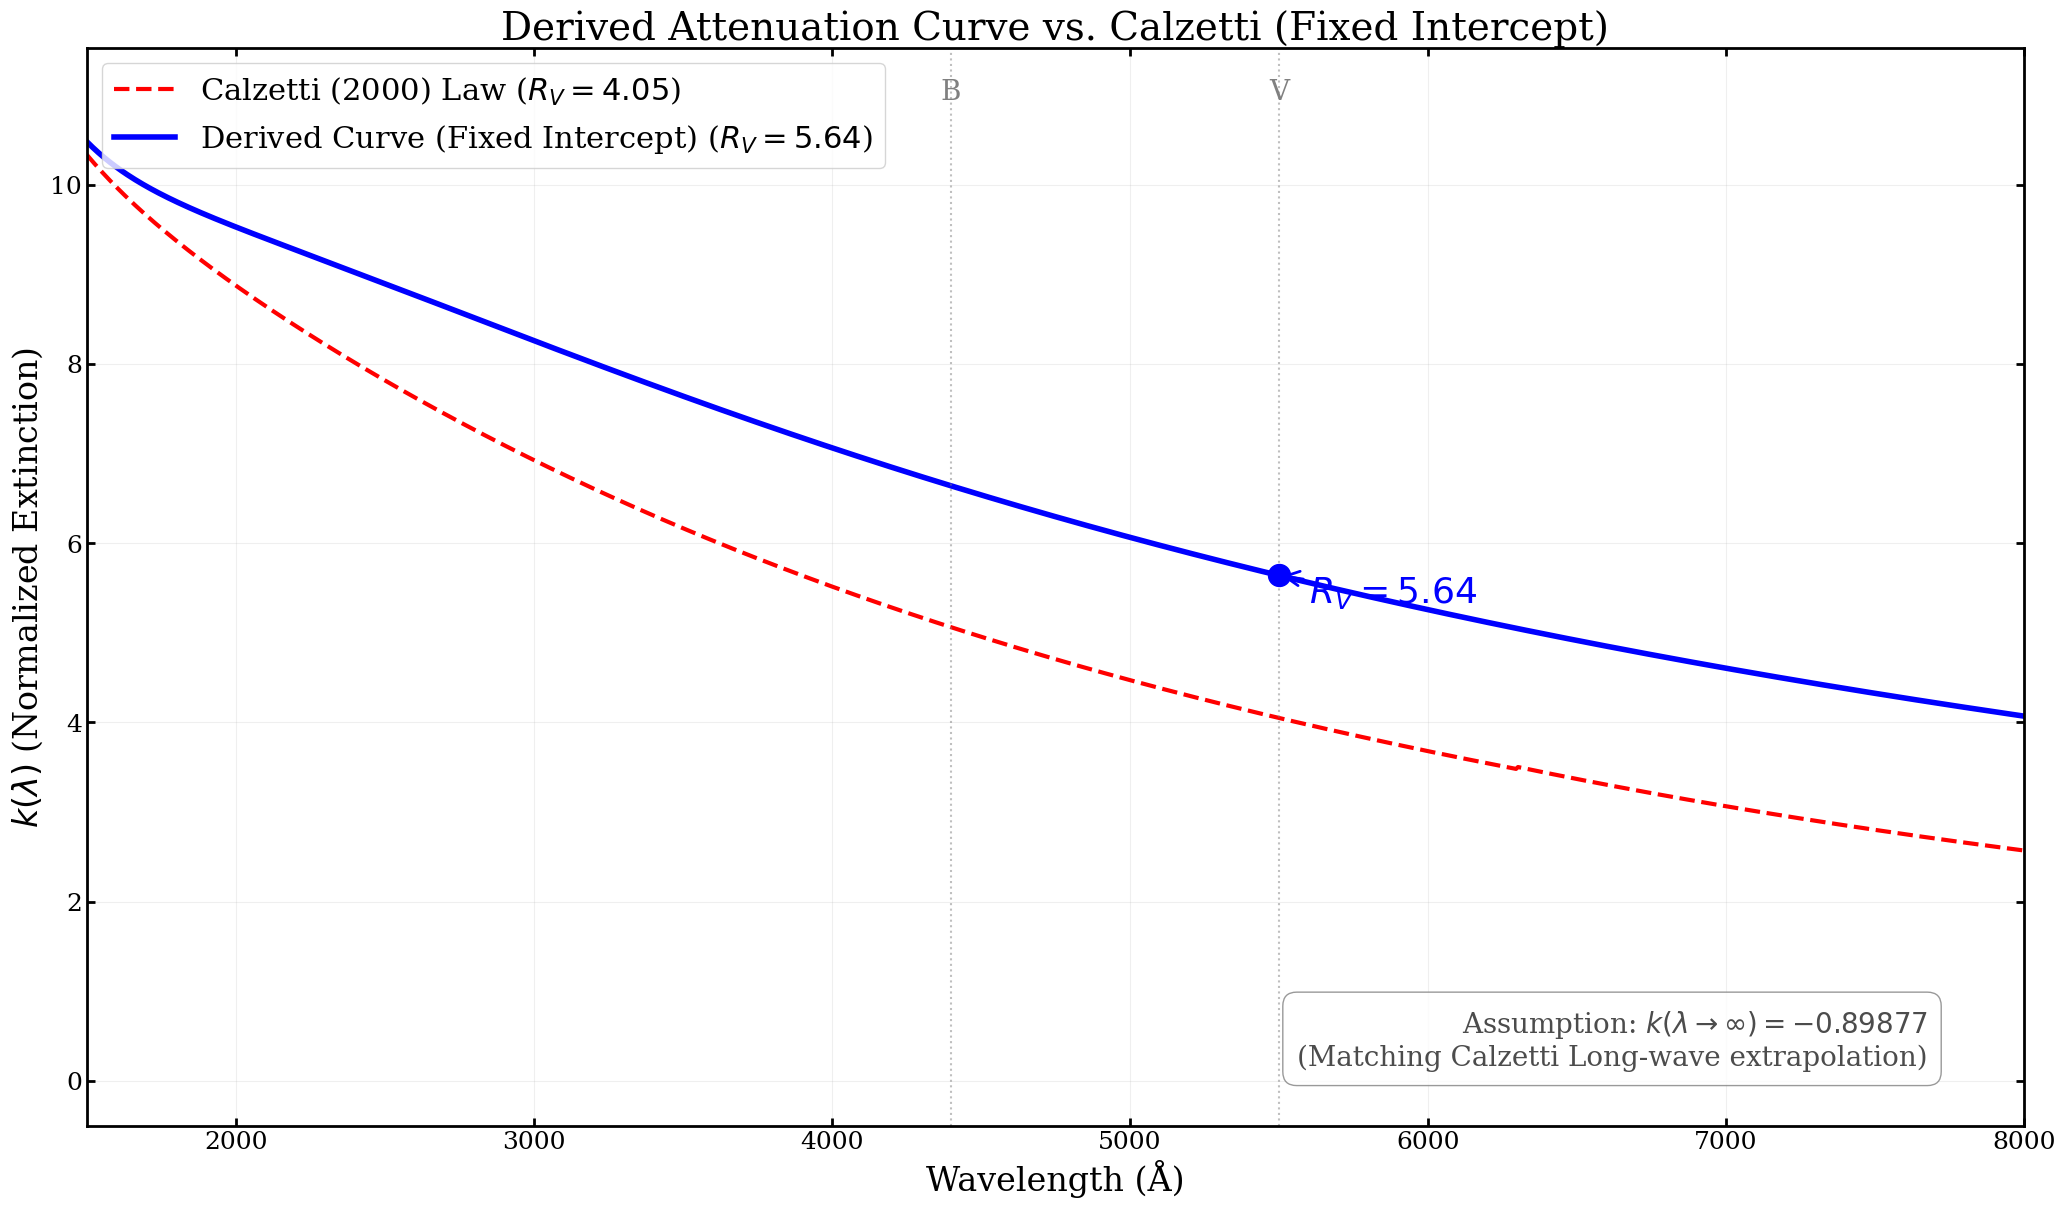

FINAL EQUATION (Shifted):
k(x) = 2.7995 * (0.0182x^3 + -0.2939x^2 + 1.7583x) -0.89877
Where x = 1/λ (μm^-1)


In [18]:

# ==========================================
# 1. 定义新的曲线方程 (带截距)
# ==========================================

# 1. 设定截距 (Infinity value at x=0)
intercept_val = -0.89877

# 2. 获取多项式形状系数 (c3, c2, c1)
# 假设 coeffs 仍然是 [c3, c2, c1, c0] 来自之前的 polyfit
# 我们只用高阶项决定形状
c3, c2, c1 = coeffs[0], coeffs[1], coeffs[2]

def poly_shape_cubic_only(x):
    """仅包含 x^3, x^2, x 项，不含常数"""
    return c3 * x**3 + c2 * x**2 + c1 * x

# 3. 计算归一化因子 S_new
# 条件: k(B) - k(V) = 1
# k(x) = S * P(x) + intercept
# k(xB) - k(xV) = S * (P(xB) - P(xV)) + (intercept - intercept)
# 截距抵消了，所以 S 的计算公式其实和上一步一样，但为了严谨我们重写一遍

x_B = 1.0 / 0.44 # 4400A in um^-1
x_V = 1.0 / 0.55 # 5500A in um^-1

val_B_shape = poly_shape_cubic_only(x_B)
val_V_shape = poly_shape_cubic_only(x_V)

scaling_factor_shifted = 1.0 / (val_B_shape - val_V_shape)

# 4. 定义最终曲线方程
def derived_k_curve_shifted(wavelength_angstrom):
    w_microns = wavelength_angstrom / 10000.0
    x = 1.0 / w_microns
    # k(x) = S * (c3x^3 + ...) + intercept
    return scaling_factor_shifted * poly_shape_cubic_only(x) + intercept_val

# ==========================================
# 2. 计算数据
# ==========================================

# 计算绘图数据
plot_wave = np.linspace(1500, 8000, 1000)
k_curve_shifted = derived_k_curve_shifted(plot_wave)

# 计算 Calzetti 曲线 (Rv=4.05)
calz_k_curve = 2.659*calzetti_law(plot_wave, Rv=4.05)+4.05

# 计算新的 Rv (5500A 处的值)
my_Rv_shifted = derived_k_curve_shifted(5500)
print(f"New Derived Rv (with intercept {intercept_val}) = {my_Rv_shifted:.3f}")

# ==========================================
# 3. 绘图
# ==========================================

fig, ax = plt.subplots(figsize=(25, 14))

# A. 绘制 Calzetti (作为基准，红色虚线)
ax.plot(plot_wave, calz_k_curve, color='red', linewidth=3, linestyle='--', label='Calzetti (2000) Law ($R_V=4.05$)')

# B. 绘制新的曲线 (蓝色实线)
ax.plot(plot_wave, k_curve_shifted, color='blue', linewidth=4, label=f'Derived Curve (Fixed Intercept) ($R_V={my_Rv_shifted:.2f}$)')

# C. 标注 5500A 处的数值 (Rv)
ax.scatter([5500], [my_Rv_shifted], color='blue', s=250, zorder=10, marker='o')
ax.annotate(f'$R_V={my_Rv_shifted:.2f}$', xy=(5500, my_Rv_shifted), xytext=(5600, my_Rv_shifted - 0.3),
            fontsize=26, color='blue', arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# D. 标注无穷远处的假设 (Long-wave end assumption)
# 我们在图的右下角或空白处写上这个假设
ax.text(0.95, 0.05, f'Assumption: $k(\lambda \\rightarrow \infty) = {intercept_val}$\n(Matching Calzetti Long-wave extrapolation)',
        transform=ax.transAxes, fontsize=20, color='black', alpha=0.7,
        horizontalalignment='right', verticalalignment='bottom',
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))

# E. 辅助线 (4400 & 5500)
ax.axvline(5500, color='gray', linestyle=':', alpha=0.5)
ax.axvline(4400, color='gray', linestyle=':', alpha=0.5)
# 在顶部标注波段
ylim_top = max(np.max(k_curve_shifted), np.max(calz_k_curve)) * 1.1
ax.text(4400, ylim_top*0.95, 'B', fontsize=20, ha='center', color='gray')
ax.text(5500, ylim_top*0.95, 'V', fontsize=20, ha='center', color='gray')

# --- 样式设置 ---
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel(r'$k(\lambda)$ (Normalized Extinction)', fontsize=24)
ax.set_title('Derived Attenuation Curve vs. Calzetti (Fixed Intercept)', fontsize=28)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=18, length=6)

ax.set_xlim(1500, 8000)
ax.set_ylim(-0.5, ylim_top) # Y轴下限稍微放低一点，展示可能存在的低值

plt.legend(fontsize=22, loc='upper left')
plt.grid(True, alpha=0.2)

plt.savefig('Derived_k_Curve_Shifted_Intercept.pdf', bbox_inches='tight', dpi=300)
plt.show()

# 打印最终方程
print("="*40)
print("FINAL EQUATION (Shifted):")
print(f"k(x) = {scaling_factor_shifted:.4f} * ({c3:.4f}x^3 + {c2:.4f}x^2 + {c1:.4f}x) {intercept_val}")
print(f"Where x = 1/λ (μm^-1)")
print("="*40)

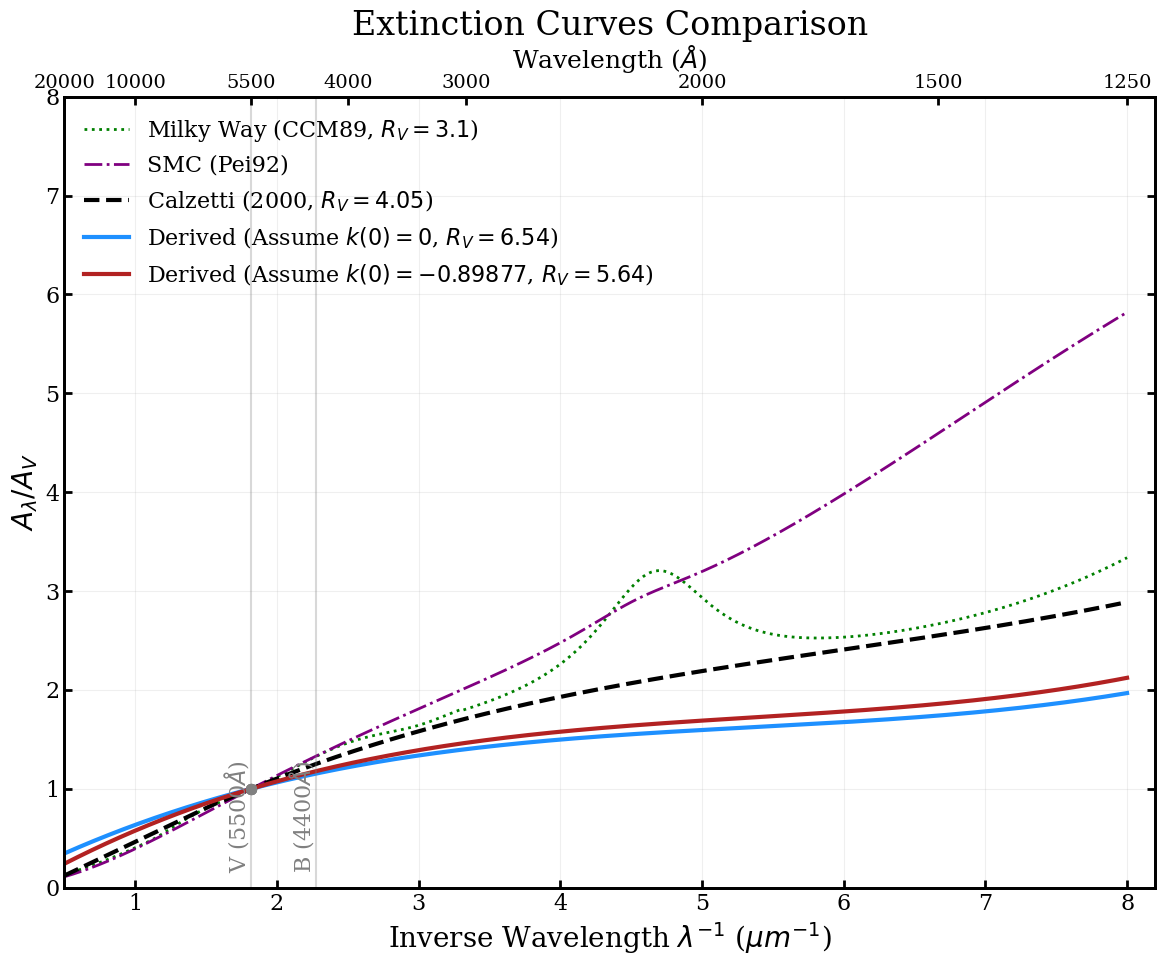

In [20]:


def get_calzetti_curve_Av(x, Rv=4.05):
    """
    Calzetti (2000) Law, normalized to A_lambda / A_V
    x: 1/lambda [um^-1]
    """
    lam_um = 1.0 / x
    k = np.zeros_like(x)

    # Range 1: 0.12um to 0.63um
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    l = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/l - 0.198/l**2 + 0.011/l**3) + Rv

    # Range 2: 0.63um to 2.2um
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    l = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/l) + Rv

    # A_lambda / A_V = k(lambda) / Rv
    return k / Rv

def get_mw_ccm89_Av(x, Rv=3.1):
    """
    Milky Way: Cardelli, Clayton, & Mathis (1989)
    Returns A_lambda / A_V
    x: 1/lambda [um^-1]
    """
    x = np.array(x)
    a = np.zeros_like(x)
    b = np.zeros_like(x)

    # 1. Infrared (0.3 <= x < 1.1)
    mask_ir = (x >= 0.3) & (x < 1.1)
    a[mask_ir] = 0.574 * x[mask_ir]**1.61
    b[mask_ir] = -0.527 * x[mask_ir]**1.61

    # 2. Optical/NIR (1.1 <= x < 3.3)
    mask_opt = (x >= 1.1) & (x < 3.3)
    y = x[mask_opt] - 1.82
    a[mask_opt] = 1 + 0.17699*y - 0.50447*y**2 - 0.02427*y**3 + 0.72085*y**4 + 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7
    b[mask_opt] = 1.41338*y + 2.28305*y**2 + 1.07233*y**3 - 5.38434*y**4 - 0.62251*y**5 + 5.30260*y**6 - 2.09002*y**7

    # 3. UV (3.3 <= x <= 8)
    mask_uv = (x >= 3.3)
    X = x[mask_uv]
    F_a = -0.04473 * (X - 5.9)**2 - 0.009779 * (X - 5.9)**3
    F_b = 0.2130 * (X - 5.9)**2 + 0.1207 * (X - 5.9)**3
    # Only apply F_a, F_b for x >= 5.9
    low_uv_mask = X < 5.9
    F_a[low_uv_mask] = 0
    F_b[low_uv_mask] = 0

    a[mask_uv] = 1.752 - 0.316*X - 0.104/((X - 4.67)**2 + 0.341) + F_a
    b[mask_uv] = -3.090 + 1.825*X + 1.206/((X - 4.67)**2 + 0.263) + F_b

    return a + b / Rv

def get_smc_pei92_Av(x):
    """
    SMC: Pei (1992) Approximation
    Returns A_lambda / A_V (Normalized to 1 at V-band)
    """
    a = [185, 27, 0.005, 0.010, 0.012, 0.030]
    w = [0.042, 0.08, 0.22, 9.7, 18, 25] # lambda_i in microns
    b = [90, 5.5, -1.95, -1.95, -1.80, 0.0]
    n = [2.0, 4.0, 2.0, 2.0, 2.0, 2.0]

    lam = 1.0 / x # microns
    ext_sum = np.zeros_like(x)

    for i in range(6):
        term = a[i] / ((lam/w[i])**n[i] + (w[i]/lam)**n[i] + b[i])
        ext_sum += term

    # Calculate normalization factor at V-band (0.55 um => x=1.818)
    lam_V = 0.55
    val_V = 0
    for i in range(6):
        val_V += a[i] / ((lam_V/w[i])**n[i] + (w[i]/lam_V)**n[i] + b[i])

    return ext_sum / val_V

# ==========================================
# 2. 准备绘图数据
# ==========================================

# X轴范围: 1/lambda [um^-1]
# 0.5 um^-1 (20000A) 到 8.0 um^-1 (1250A)
x_grid = np.linspace(0.5, 8.0, 1000)

# A. 计算参考曲线
y_calzetti = get_calzetti_curve_Av(x_grid, Rv=4.05)
y_mw = get_mw_ccm89_Av(x_grid, Rv=3.1)
y_smc = get_smc_pei92_Av(x_grid)

# B. 计算 Derived Curve 1: 假设无穷远处为 0 (Assumption 0)
# 使用之前的 coeffs, scaling_factor, my_Rv
# 形状函数 P(x) = c3*x^3 + c2*x^2 + c1*x
# k(x) = S * P(x)
# A/Av = k(x) / Rv
def get_derived_zero_Av(x):
    # 重建形状
    c3, c2, c1 = coeffs[0], coeffs[1], coeffs[2]
    shape = c3 * x**3 + c2 * x**2 + c1 * x
    k_val = scaling_factor * shape
    return k_val / my_Rv # 归一化

y_derived_zero = get_derived_zero_Av(x_grid)

# C. 计算 Derived Curve 2: 假设无穷远处为 Calzetti End (Assumption Calzetti)
# 使用之前的 coeffs, scaling_factor_shifted, intercept_val, my_Rv_shifted
# k(x) = S * P(x) + intercept
def get_derived_shifted_Av(x):
    c3, c2, c1 = coeffs[0], coeffs[1], coeffs[2]
    shape = c3 * x**3 + c2 * x**2 + c1 * x
    k_val = scaling_factor_shifted * shape + intercept_val
    return k_val / my_Rv_shifted # 归一化

y_derived_shifted = get_derived_shifted_Av(x_grid)

# ==========================================
# 3. 绘图
# ==========================================

fig, ax = plt.subplots(figsize=(12, 10))

# 1. 绘制参考线
ax.plot(x_grid, y_mw, color='green', linestyle=':', linewidth=2, label='Milky Way (CCM89, $R_V=3.1$)')
ax.plot(x_grid, y_smc, color='purple', linestyle='-.', linewidth=2, label='SMC (Pei92)')
ax.plot(x_grid, y_calzetti, color='black', linestyle='--', linewidth=3, label='Calzetti (2000, $R_V=4.05$)')

# 2. 绘制你的 Derived Curves
ax.plot(x_grid, y_derived_zero, color='dodgerblue', linewidth=3,
        label=f'Derived (Assume $k(0)=0$, $R_V={my_Rv:.2f}$)')

ax.plot(x_grid, y_derived_shifted, color='firebrick', linewidth=3, linestyle='-',
        label=f'Derived (Assume $k(0)={intercept_val}$, $R_V={my_Rv_shifted:.2f}$)')

# 3. 标注 V 波段位置 (归一化点)
x_V = 1.0 / 0.55 # ~1.82
ax.axvline(x_V, color='gray', linestyle='-', alpha=0.3)
ax.scatter([x_V]*5, [1]*5, color='gray', s=50, zorder=10)
ax.text(x_V, 0.2, 'V (5500$\AA$)', rotation=90, color='gray', fontsize=16, ha='right')

# 4. 标注 B 波段位置
x_B = 1.0 / 0.44 # ~2.27
ax.axvline(x_B, color='gray', linestyle='-', alpha=0.3)
ax.text(x_B, 0.2, 'B (4400$\AA$)', rotation=90, color='gray', fontsize=16, ha='right')

# --- 样式设置 ---
ax.set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=20)
ax.set_ylabel(r'$A_\lambda / A_V$', fontsize=20)
ax.set_title('Extinction Curves Comparison', fontsize=24)

# 坐标轴范围
ax.set_xlim(0.5, 8.2) # 涵盖到 1216A 附近
ax.set_ylim(0, 8)     # 根据 UV 上升情况调整

# 辅助坐标轴 (顶部显示波长)
ax2 = ax.twiny()
ax2_ticks = np.array([20000, 10000, 5500, 4000, 3000, 2000, 1500, 1250])
ax2_tick_locs = 10000.0 / ax2_ticks
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(ax2_tick_locs)
ax2.set_xticklabels([f"{int(t)}" for t in ax2_ticks], fontsize=14)
ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=18)

# 边框与刻度
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6, direction='in')
ax.tick_params(axis='both', which='minor', width=1.5, length=3, direction='in')
for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.legend(fontsize=16, loc='upper left', frameon=False)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('Extinction_Curve_Comparison_InverseLambda.pdf', bbox_inches='tight', dpi=300)
plt.show()

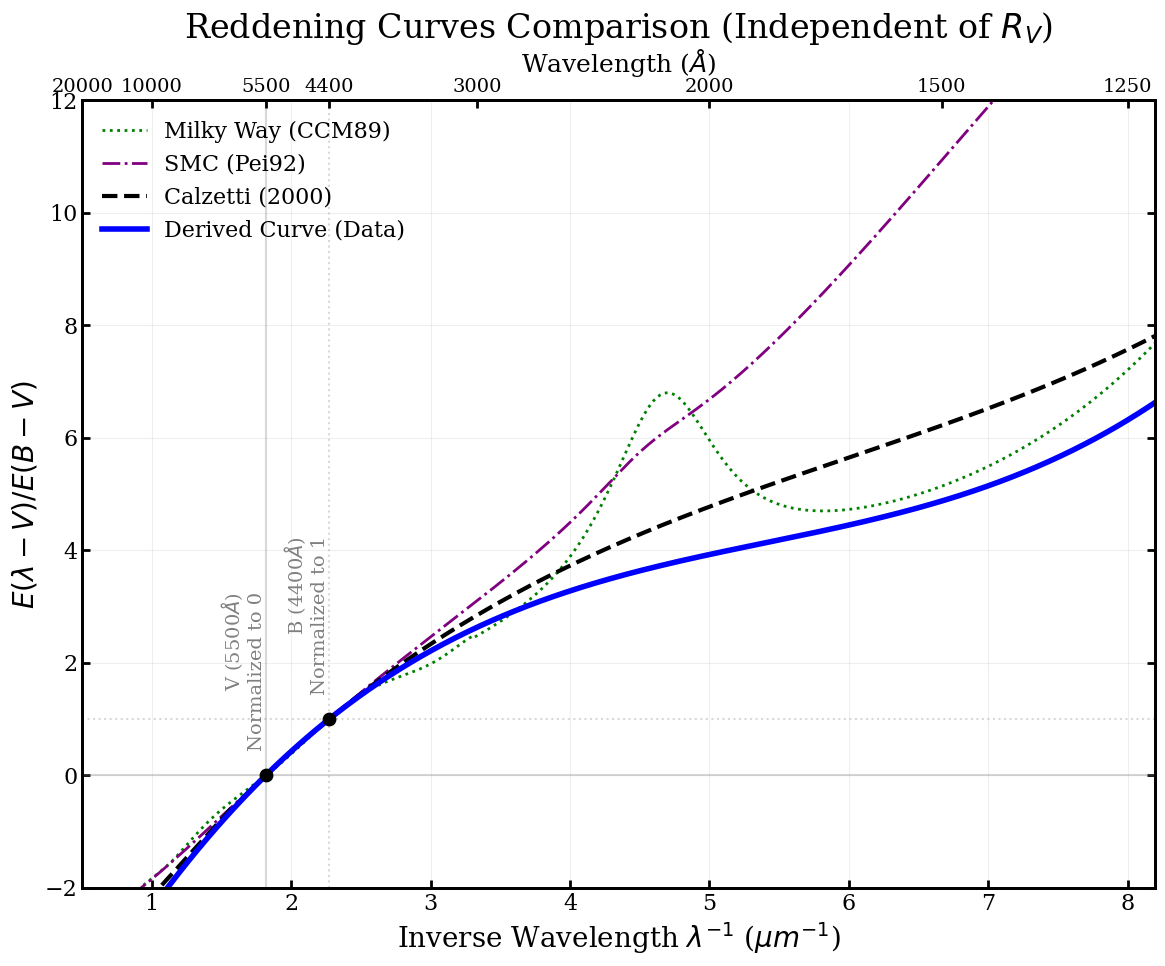

This plot shows the intrinsic shape of the attenuation curve, free from Rv assumptions.


In [78]:


# ==========================================
# 1. 准备工作：定义转化函数
# ==========================================

def get_curve_E_lambda_V_normalized(x_grid, curve_type='derived'):
    """
    计算 (A_lambda - A_V) / E(B-V)
    这等同于 k(lambda) - R_V
    """
    # 定义波段对应的 1/lambda
    x_V = 1.0 / 0.55  # ~1.82 um^-1
    x_B = 1.0 / 0.44  # ~2.27 um^-1

    if curve_type == 'derived':
        # 使用你的多项式系数 (来自之前的拟合)
        # coeffs = [c3, c2, c1, c0]
        # P(x) = c3*x^3 + c2*x^2 + c1*x (常数项 c0 无论是什么，在相减时都会抵消，所以忽略)
        c3, c2, c1 = coeffs[0], coeffs[1], coeffs[2]

        def shape(x):
            return c3 * x**3 + c2 * x**2 + c1 * x

        val_grid = shape(x_grid)
        val_V = shape(x_V)
        val_B = shape(x_B)

        # 公式: (P(x) - P(V)) / (P(B) - P(V))
        return (val_grid - val_V) / (val_B - val_V)

    elif curve_type == 'calzetti':
        # Calzetti k(lambda)
        # 这里的 k 已经是 A_lambda / E(B-V)
        k_grid = get_calzetti_curve_Av(x_grid, Rv=4.05) * 4.05 # 还原回 k
        k_V = 4.05 # Calzetti 的 R_V
        k_B = get_calzetti_curve_Av(np.array([x_B]), Rv=4.05)[0] * 4.05

        # 理论上 k(lambda) - Rv 就行，但为了数值精确对齐，我们做一次差分归一化
        return (k_grid - k_V) / (k_B - k_V)

    elif curve_type == 'mw':
        # CCM89 返回的是 A/Av
        # 我们需要转为 (A/Av * Rv - Rv) / (Ab/Av * Rv - Rv) = (A/Av - 1) / (Ab/Av - 1)
        # 这样 Rv 就消掉了，只看形状
        y_grid = get_mw_ccm89_Av(x_grid, Rv=3.1)
        y_V = 1.0
        y_B = get_mw_ccm89_Av(np.array([x_B]), Rv=3.1)[0]
        return (y_grid - y_V) / (y_B - y_V)

    elif curve_type == 'smc':
        y_grid = get_smc_pei92_Av(x_grid)
        y_V = 1.0
        y_B = get_smc_pei92_Av(np.array([x_B]))[0]
        return (y_grid - y_V) / (y_B - y_V)

# ==========================================
# 2. 计算数据
# ==========================================

x_grid = np.linspace(0.5, 8.2, 1000) # 0.5 um^-1 到 8.2 um^-1

y_derived = get_curve_E_lambda_V_normalized(x_grid, 'derived')
y_calzetti = get_curve_E_lambda_V_normalized(x_grid, 'calzetti')
y_mw = get_curve_E_lambda_V_normalized(x_grid, 'mw')
y_smc = get_curve_E_lambda_V_normalized(x_grid, 'smc')

# ==========================================
# 3. 绘图
# ==========================================

fig, ax = plt.subplots(figsize=(12, 10))

# 绘制参考线
ax.plot(x_grid, y_mw, color='green', linestyle=':', linewidth=2, label='Milky Way (CCM89)')
ax.plot(x_grid, y_smc, color='purple', linestyle='-.', linewidth=2, label='SMC (Pei92)')
ax.plot(x_grid, y_calzetti, color='black', linestyle='--', linewidth=3, label='Calzetti (2000)')

# 绘制你的曲线 (不需要假设截距了！)
ax.plot(x_grid, y_derived, color='blue', linewidth=4, label='Derived Curve (Data)')

# 标注 V 和 B 波段
x_V = 1.0 / 0.55
x_B = 1.0 / 0.44

# 零点线 (V波段)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(x_V, color='gray', linestyle='-', alpha=0.3)
ax.scatter([x_V], [0], color='black', s=80, zorder=10)
ax.text(x_V, 0.5, 'V (5500$\AA$)\nNormalized to 0', rotation=90, color='gray', fontsize=14, ha='right')

# 归一化点 (B波段)
ax.axhline(1, color='gray', linestyle=':', alpha=0.3)
ax.axvline(x_B, color='gray', linestyle=':', alpha=0.3)
ax.scatter([x_B], [1], color='black', s=80, zorder=10)
ax.text(x_B, 1.5, 'B (4400$\AA$)\nNormalized to 1', rotation=90, color='gray', fontsize=14, ha='right')

# --- 样式设置 ---
ax.set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=20)
ax.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=20)
ax.set_title(r'Reddening Curves Comparison (Independent of $R_V$)', fontsize=24)

# 坐标轴范围
ax.set_xlim(0.5, 8.2)
# y轴范围通常在 -2 到 10+ 之间
ax.set_ylim(-2, 12)

# 顶部波长轴
ax2 = ax.twiny()
ax2_ticks = np.array([20000, 10000, 5500, 4400, 3000, 2000, 1500, 1250])
ax2_tick_locs = 10000.0 / ax2_ticks
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(ax2_tick_locs)
ax2.set_xticklabels([f"{int(t)}" for t in ax2_ticks], fontsize=14)
ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=18)

# 边框与刻度
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6, direction='in')
for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.legend(fontsize=16, loc='upper left', frameon=False)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('Reddening_Curve_Comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

print("This plot shows the intrinsic shape of the attenuation curve, free from Rv assumptions.")

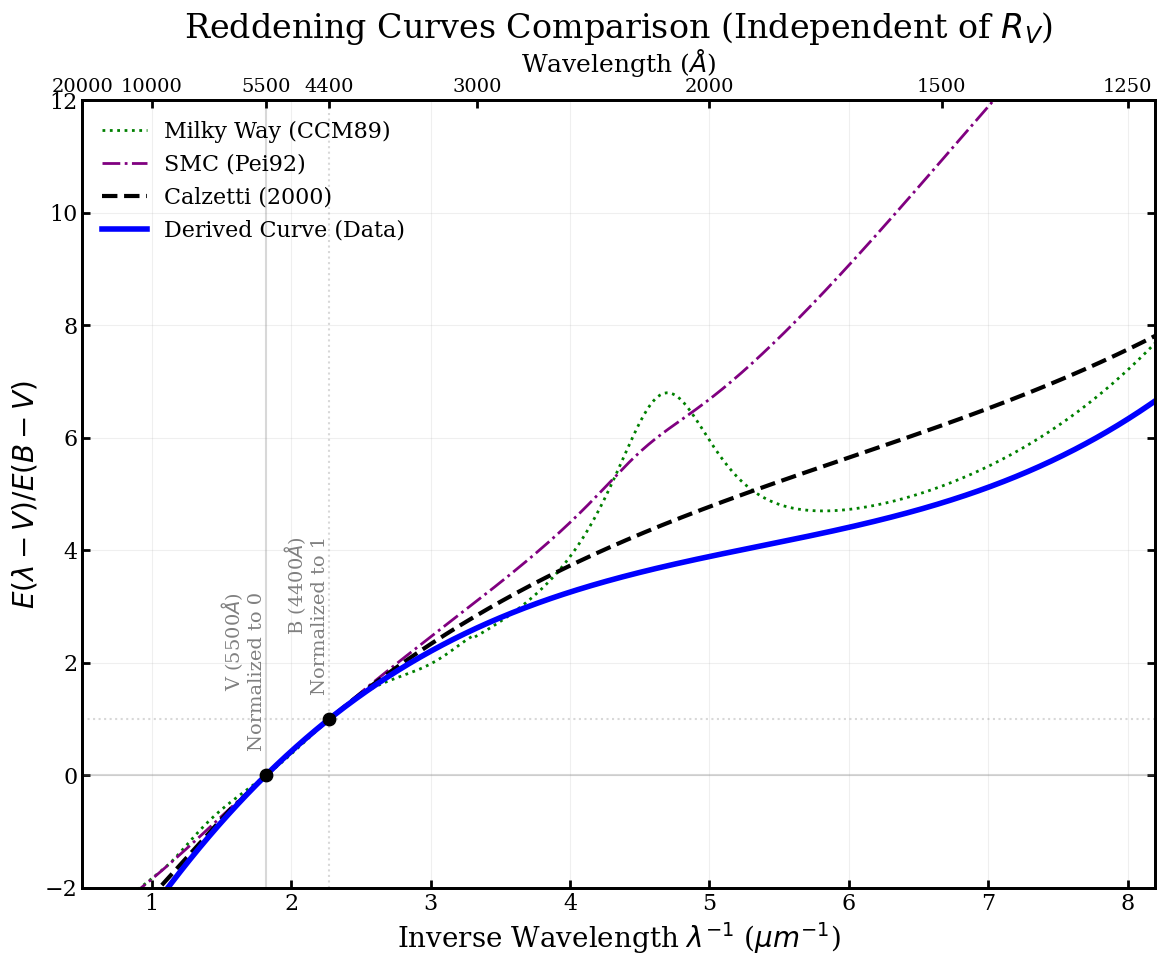

This plot shows the intrinsic shape of the attenuation curve, free from Rv assumptions.


In [21]:


# ==========================================
# 1. 准备工作：定义转化函数
# ==========================================

def get_curve_E_lambda_V_normalized(x_grid, curve_type='derived'):
    """
    计算 (A_lambda - A_V) / E(B-V)
    这等同于 k(lambda) - R_V
    """
    # 定义波段对应的 1/lambda
    x_V = 1.0 / 0.55  # ~1.82 um^-1
    x_B = 1.0 / 0.44  # ~2.27 um^-1

    if curve_type == 'derived':
        # 使用你的多项式系数 (来自之前的拟合)
        # coeffs = [c3, c2, c1, c0]
        # P(x) = c3*x^3 + c2*x^2 + c1*x (常数项 c0 无论是什么，在相减时都会抵消，所以忽略)
        c3, c2, c1 = coeffs[0], coeffs[1], coeffs[2]

        def shape(x):
            return c3 * x**3 + c2 * x**2 + c1 * x

        val_grid = shape(x_grid)
        val_V = shape(x_V)
        val_B = shape(x_B)

        # 公式: (P(x) - P(V)) / (P(B) - P(V))
        return (val_grid - val_V) / (val_B - val_V)

    elif curve_type == 'calzetti':
        # Calzetti k(lambda)
        # 这里的 k 已经是 A_lambda / E(B-V)
        k_grid = get_calzetti_curve_Av(x_grid, Rv=4.05) * 4.05 # 还原回 k
        k_V = 4.05 # Calzetti 的 R_V
        k_B = get_calzetti_curve_Av(np.array([x_B]), Rv=4.05)[0] * 4.05

        # 理论上 k(lambda) - Rv 就行，但为了数值精确对齐，我们做一次差分归一化
        return (k_grid - k_V) / (k_B - k_V)

    elif curve_type == 'mw':
        # CCM89 返回的是 A/Av
        # 我们需要转为 (A/Av * Rv - Rv) / (Ab/Av * Rv - Rv) = (A/Av - 1) / (Ab/Av - 1)
        # 这样 Rv 就消掉了，只看形状
        y_grid = get_mw_ccm89_Av(x_grid, Rv=3.1)
        y_V = 1.0
        y_B = get_mw_ccm89_Av(np.array([x_B]), Rv=3.1)[0]
        return (y_grid - y_V) / (y_B - y_V)

    elif curve_type == 'smc':
        y_grid = get_smc_pei92_Av(x_grid)
        y_V = 1.0
        y_B = get_smc_pei92_Av(np.array([x_B]))[0]
        return (y_grid - y_V) / (y_B - y_V)

# ==========================================
# 2. 计算数据
# ==========================================

x_grid = np.linspace(0.5, 8.2, 1000) # 0.5 um^-1 到 8.2 um^-1

y_derived = get_curve_E_lambda_V_normalized(x_grid, 'derived')
y_calzetti = get_curve_E_lambda_V_normalized(x_grid, 'calzetti')
y_mw = get_curve_E_lambda_V_normalized(x_grid, 'mw')
y_smc = get_curve_E_lambda_V_normalized(x_grid, 'smc')

# ==========================================
# 3. 绘图
# ==========================================

fig, ax = plt.subplots(figsize=(12, 10))

# 绘制参考线
ax.plot(x_grid, y_mw, color='green', linestyle=':', linewidth=2, label='Milky Way (CCM89)')
ax.plot(x_grid, y_smc, color='purple', linestyle='-.', linewidth=2, label='SMC (Pei92)')
ax.plot(x_grid, y_calzetti, color='black', linestyle='--', linewidth=3, label='Calzetti (2000)')

# 绘制你的曲线 (不需要假设截距了！)
ax.plot(x_grid, y_derived, color='blue', linewidth=4, label='Derived Curve (Data)')

# 标注 V 和 B 波段
x_V = 1.0 / 0.55
x_B = 1.0 / 0.44

# 零点线 (V波段)
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(x_V, color='gray', linestyle='-', alpha=0.3)
ax.scatter([x_V], [0], color='black', s=80, zorder=10)
ax.text(x_V, 0.5, 'V (5500$\AA$)\nNormalized to 0', rotation=90, color='gray', fontsize=14, ha='right')

# 归一化点 (B波段)
ax.axhline(1, color='gray', linestyle=':', alpha=0.3)
ax.axvline(x_B, color='gray', linestyle=':', alpha=0.3)
ax.scatter([x_B], [1], color='black', s=80, zorder=10)
ax.text(x_B, 1.5, 'B (4400$\AA$)\nNormalized to 1', rotation=90, color='gray', fontsize=14, ha='right')

# --- 样式设置 ---
ax.set_xlabel(r'Inverse Wavelength $\lambda^{-1}$ ($\mu m^{-1}$)', fontsize=20)
ax.set_ylabel(r'$E(\lambda - V) / E(B - V)$', fontsize=20)
ax.set_title(r'Reddening Curves Comparison (Independent of $R_V$)', fontsize=24)

# 坐标轴范围
ax.set_xlim(0.5, 8.2)
# y轴范围通常在 -2 到 10+ 之间
ax.set_ylim(-2, 12)

# 顶部波长轴
ax2 = ax.twiny()
ax2_ticks = np.array([20000, 10000, 5500, 4400, 3000, 2000, 1500, 1250])
ax2_tick_locs = 10000.0 / ax2_ticks
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(ax2_tick_locs)
ax2.set_xticklabels([f"{int(t)}" for t in ax2_ticks], fontsize=14)
ax2.set_xlabel(r'Wavelength ($\AA$)', fontsize=18)

# 边框与刻度
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6, direction='in')
for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.legend(fontsize=16, loc='upper left', frameon=False)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('Reddening_Curve_Comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

print("This plot shows the intrinsic shape of the attenuation curve, free from Rv assumptions.")

---
# in the following section. i will derive the attenuation curve from the average spectrum.

In [13]:
from scipy.optimize import curve_fit
wave = np.array(averager.common_wavelength)  # 单位: Angstrom
Q_curve = np.array(effective_attenuation_curve)


Zero-point Shift C: -1.0849
------------------------------
Value at B (from fit, unscaled): 1.2933
Value at V (from fit, unscaled): 1.0451
Scaling Factor: 4.0288
------------------------------
Measured R_V (z=3-7): 4.2104
------------------------------


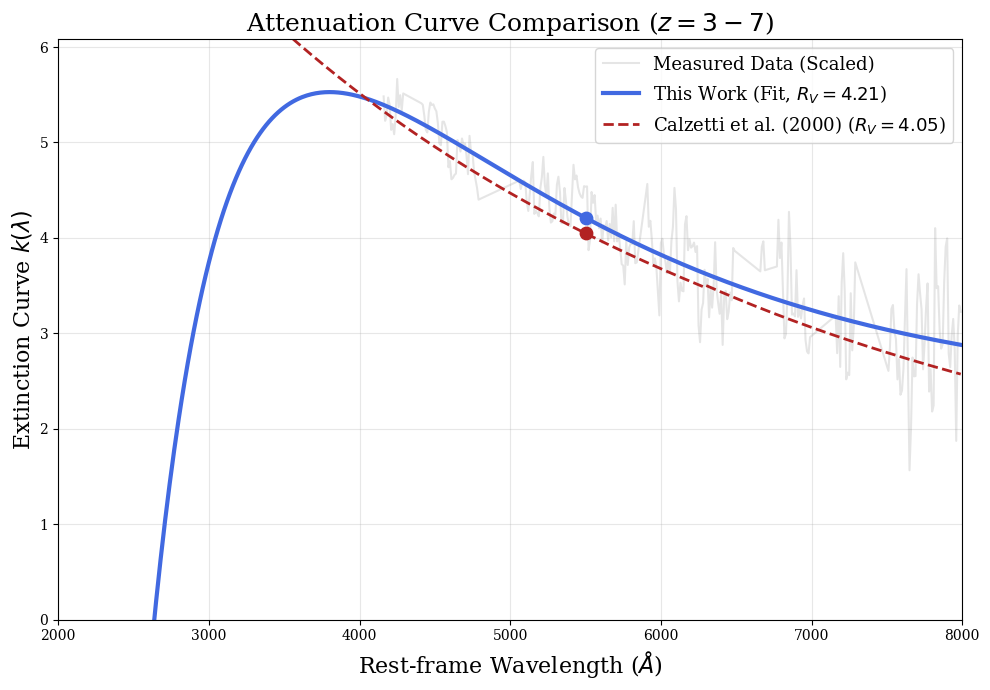


=== Final Curve Polynomial Coefficients ===
Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)
a = 5.1298
b = -7.0784
c = 5.5546
d = -1.0668

Derived R_V = k(0.55um) = 4.2104


In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# 1. 准备数据 & Mask
# ==========================================
wave = np.array(averager.common_wavelength)  # Angstrom
Q_curve = np.array(effective_attenuation_curve)

# 定义强发射线区域 (会被排除在计算之外)
mask_regions = [
    (800,4100),
    (3800,4150),
    (4300, 4400),  # Ca II H+K
    (4800, 5050),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
    (5850,5900),
    (6500, 6650),  # H-alpha (6563) + [NII]
    (6700, 6760) ,  # [SII] Doublet
    (7000,7150),
    (7300,7500)
]

is_continuum = np.ones_like(wave, dtype=bool)
for start, end in mask_regions:
    is_continuum &= ~((wave >= start) & (wave <= end))

# 排除数据中的 NaN 和 Inf
valid_data = np.isfinite(Q_curve) & np.isfinite(wave)
is_continuum &= valid_data

# ==========================================
# 2. 长波平移 (Zero-Point Shift)
# ==========================================
# 使用 1/lambda 拟合 6000-8000A 的连续谱，使其趋于 0# ==========================================
# 2. 长波平移 (Zero-Point Shift)
# ==========================================
mask_tail = (wave > 6000) & (wave < 8000) & is_continuum
def tail_func(lam, A, C):
    return A * (lam/5500)**(-1) + C

if np.sum(mask_tail) > 10:
    popt_tail, _ = curve_fit(tail_func, wave[mask_tail], Q_curve[mask_tail])
    C_shift = popt_tail[1]
else:
    C_shift = 0.0

Q_shifted = Q_curve - C_shift
print(f"Zero-point Shift C: {C_shift:.4f}")

# ==========================================
# 3. 多项式拟合 (先拟合，再归一化)
# ==========================================

# 定义多项式模型 (x = 1/lambda_micron)
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

# 准备拟合数据 (单位转换: Angstrom -> Micron)
microns = wave / 10000.0
fit_mask = (wave > 1250) & (wave < 8000) & is_continuum # 拟合范围

# 对 Q_shifted (未归一化) 进行拟合
popt_Q, _ = curve_fit(poly_model, microns[fit_mask], Q_shifted[fit_mask])

# 生成光滑的 Q 拟合曲线
Q_smooth = poly_model(microns, *popt_Q)

# ==========================================
# 4. 计算归一化因子 & Rv
# ==========================================
# 直接从光滑拟合曲线上取值，消除噪点影响
val_B_smooth = poly_model(0.4400, *popt_Q) # 4400A = 0.44um
val_V_smooth = poly_model(0.5500, *popt_Q) # 5500A = 0.55um

# 计算缩放因子 S
scaling_factor = 1.0 / (val_B_smooth - val_V_smooth)

# 计算最终的 k 曲线和 Rv
k_fit = Q_smooth * scaling_factor
k_data_scaled = Q_shifted * scaling_factor # 原始数据也乘同样的因子，用于画背景

# Rv 就是归一化后的曲线在 V 波段的值
Rv_measured = val_V_smooth * scaling_factor

print("-" * 30)
print(f"Value at B (from fit, unscaled): {val_B_smooth:.4f}")
print(f"Value at V (from fit, unscaled): {val_V_smooth:.4f}")
print(f"Scaling Factor: {scaling_factor:.4f}")
print("-" * 30)
print(f"Measured R_V (z=3-7): {Rv_measured:.4f}")
print("-" * 30)

# ==========================================
# 5. 生成 Calzetti 对比曲线
# ==========================================
def calzetti_2000_law(lam_angstroms, Rv=4.05):
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k

k_standard = calzetti_2000_law(wave)

# ==========================================
# 6. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# 1. 原始数据 (归一化后的) - 作为背景
ax.plot(wave[is_continuum], k_data_scaled[is_continuum], color='gray', alpha=0.2, label='Measured Data (Scaled)')

# 2. 你的拟合结果 (k_fit)
plot_range = (wave > 1300) & (wave < 8000)
ax.plot(wave[plot_range], k_fit[plot_range], color='royalblue', linewidth=3,
        label=f'This Work (Fit, $R_V={Rv_measured:.2f}$)')

# 3. Calzetti 标准曲线
ax.plot(wave[plot_range], k_standard[plot_range], color='firebrick', linestyle='--', linewidth=2,
        label='Calzetti et al. (2000) ($R_V=4.05$)')

# 标注 Rv
v_wave = 5500
ax.scatter([v_wave], [Rv_measured], s=80, color='royalblue', zorder=10)
ax.scatter([v_wave], [4.05], s=80, color='firebrick', zorder=10)

# 装饰
ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=16)
ax.set_ylabel(r'Extinction Curve $k(\lambda)$', fontsize=16)
ax.set_title(r'Attenuation Curve Comparison ($z=3-7$)', fontsize=18)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(2000, 8000)
# 限制Y轴，防止紫外端发散影响显示
y_max = np.max(k_fit[(wave>2000)&(wave<8000)]) * 1.1
ax.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

# ==========================================
# 7. 输出最终公式系数
# ==========================================
# k_fit = Q_smooth * S
# Q_smooth = a + b/x + ...
# 所以 k_fit 的系数就是原来的系数 * S
final_coeffs = popt_Q * scaling_factor

print("\n=== Final Curve Polynomial Coefficients ===")
print("Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)")
print(f"a = {final_coeffs[0]:.4f}")
print(f"b = {final_coeffs[1]:.4f}")
print(f"c = {final_coeffs[2]:.4f}")
print(f"d = {final_coeffs[3]:.4f}")
print(f"\nDerived R_V = k(0.55um) = {Rv_measured:.4f}")

拟合得到的 d 系数: 0.00000
------------------------------
Scaling Factor: 3.9665
Measured R_V (z=3-7): 4.1337
------------------------------


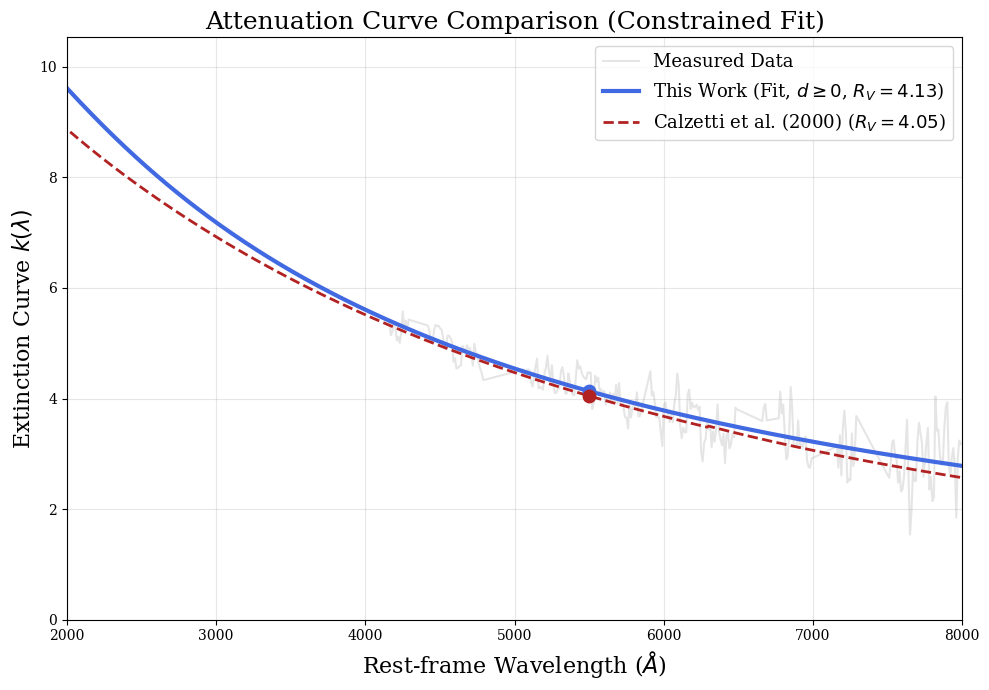


=== Final Constrained Polynomial Coefficients ===
Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)
a = -0.5904
b = 2.9169
c = -0.1752
d = 0.0000 (Constraint: d >= 0)

Derived R_V = 4.1337


In [88]:
mask_tail = (wave > 6000) & (wave < 8000) & is_continuum
def tail_func(lam, A, C):
    return A * (lam/5500)**(-1) + C

if np.sum(mask_tail) > 10:
    popt_tail, _ = curve_fit(tail_func, wave[mask_tail], Q_curve[mask_tail])
    C_shift = popt_tail[1]
else:
    C_shift = 0.0

Q_shifted = Q_curve - C_shift

# ==========================================
# 3. 约束拟合 (Constrained Fitting)
# ==========================================

# 定义多项式模型 (x = 1/lambda_micron)
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

microns = wave / 10000.0
fit_mask = (wave > 1250) & (wave < 8000) & is_continuum

# --- 关键修改：添加 bounds 参数 ---
# 参数顺序: a, b, c, d
# 下限: a,b,c 无限制 (-inf), d >= 0
# 上限: 全部无限制 (+inf)
lower_bounds = [-np.inf, -np.inf, -np.inf, 0.0]
upper_bounds = [np.inf, np.inf, np.inf, np.inf]

# 建议提供一个满足约束的初始猜测 (p0)，有助于收敛
p0_guess = [0, 0, 0, 0.1]

popt_Q, pcov_Q = curve_fit(
    poly_model,
    microns[fit_mask],
    Q_shifted[fit_mask],
    p0=p0_guess,
    bounds=(lower_bounds, upper_bounds) # <--- 强制 d >= 0
)

# 生成光滑的 Q 拟合曲线
Q_smooth = poly_model(microns, *popt_Q)

# 检查 d 是否真的非负
print(f"拟合得到的 d 系数: {popt_Q[3]:.5f}")

# ==========================================
# 4. 计算归一化因子 & Rv
# ==========================================
# 从光滑拟合曲线上取值
val_B_smooth = poly_model(0.4400, *popt_Q)
val_V_smooth = poly_model(0.5500, *popt_Q)

# 计算缩放因子 S
scaling_factor = 1.0 / (val_B_smooth - val_V_smooth)

# 计算最终的 k 曲线
k_fit = Q_smooth * scaling_factor
k_data_scaled = Q_shifted * scaling_factor

# Rv 就是归一化后的曲线在 V 波段的值
Rv_measured = val_V_smooth * scaling_factor

print("-" * 30)
print(f"Scaling Factor: {scaling_factor:.4f}")
print(f"Measured R_V (z=3-7): {Rv_measured:.4f}")
print("-" * 30)

# ==========================================
# 5. 生成 Calzetti 对比曲线 (略微简化代码)
# ==========================================
def calzetti_2000_law(lam_angstroms, Rv=4.05):
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k

k_standard = calzetti_2000_law(wave)

# ==========================================
# 6. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# 背景数据
ax.plot(wave[fit_mask], k_data_scaled[fit_mask], color='gray', alpha=0.2, label='Measured Data')

# 你的拟合 (约束 d>0)
plot_range = (wave > 1300) & (wave < 8000)
ax.plot(wave[plot_range], k_fit[plot_range], color='royalblue', linewidth=3,
        label=f'This Work (Fit, $d \geq 0$, $R_V={Rv_measured:.2f}$)')

# Calzetti
ax.plot(wave[plot_range], k_standard[plot_range], color='firebrick', linestyle='--', linewidth=2,
        label='Calzetti et al. (2000) ($R_V=4.05$)')

# 标注 Rv
v_wave = 5500
ax.scatter([v_wave], [Rv_measured], s=80, color='royalblue', zorder=10)
ax.scatter([v_wave], [4.05], s=80, color='firebrick', zorder=10)

ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=16)
ax.set_ylabel(r'Extinction Curve $k(\lambda)$', fontsize=16)
ax.set_title(r'Attenuation Curve Comparison (Constrained Fit)', fontsize=18)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(2000, 8000)
y_max = np.max(k_fit[(wave>2000)&(wave<8000)]) * 1.1
ax.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

# ==========================================
# 7. 输出最终公式系数
# ==========================================
final_coeffs = popt_Q * scaling_factor

print("\n=== Final Constrained Polynomial Coefficients ===")
print("Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)")
print(f"a = {final_coeffs[0]:.4f}")
print(f"b = {final_coeffs[1]:.4f}")
print(f"c = {final_coeffs[2]:.4f}")
print(f"d = {final_coeffs[3]:.4f} (Constraint: d >= 0)")
print(f"\nDerived R_V = {Rv_measured:.4f}")

Zero-point Shift C: -1.0849
------------------------------
Value at B (from fit, unscaled): 1.4342
Value at V (from fit, unscaled): 1.1042
Scaling Factor: 3.0306
------------------------------
Measured R_V (z=3-7): 3.3464
------------------------------


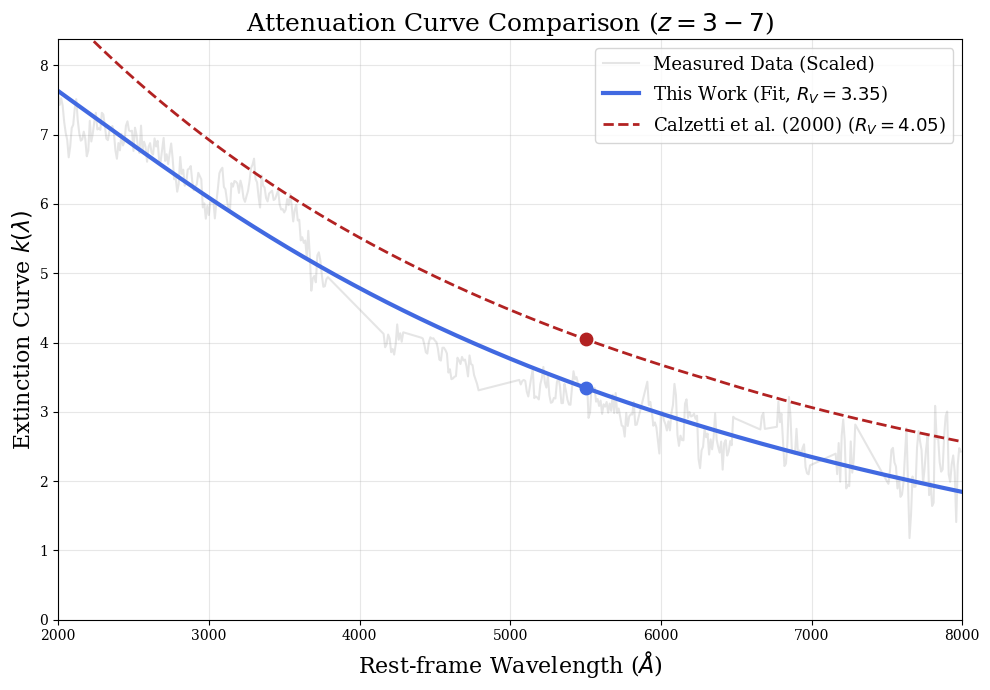


=== Final Curve Polynomial Coefficients ===
Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)
a = -2.6114
b = 4.2711
c = -0.6053
d = 0.0321

Derived R_V = k(0.55um) = 3.3464


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# 1. 准备数据 & Mask
# ==========================================
wave = np.array(averager.common_wavelength)  # Angstrom
Q_curve = np.array(effective_attenuation_curve)

# 定义强发射线区域 (会被排除在计算之外)
mask_regions = [

    (3800,4150),
    (4300, 4400),  # Ca II H+K
    (4800, 5050),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
    (5850,5900),
    (6500, 6650),  # H-alpha (6563) + [NII]
    (6700, 6760) ,  # [SII] Doublet
    (7000,7150),
    (7300,7500)
]

is_continuum = np.ones_like(wave, dtype=bool)
for start, end in mask_regions:
    is_continuum &= ~((wave >= start) & (wave <= end))

# 排除数据中的 NaN 和 Inf
valid_data = np.isfinite(Q_curve) & np.isfinite(wave)
is_continuum &= valid_data
# ==========================================
# 2. 长波平移 (Zero-Point Shift)
# ==========================================
mask_tail = (wave > 6000) & (wave < 8000) & is_continuum
def tail_func(lam, A, C):
    return A * (lam/5500)**(-1) + C

if np.sum(mask_tail) > 10:
    popt_tail, _ = curve_fit(tail_func, wave[mask_tail], Q_curve[mask_tail])
    C_shift = popt_tail[1]
else:
    C_shift = 0.0

Q_shifted = Q_curve - C_shift
print(f"Zero-point Shift C: {C_shift:.4f}")

# ==========================================
# 3. 多项式拟合 (先拟合，再归一化)
# ==========================================

# 定义多项式模型 (x = 1/lambda_micron)
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

# 准备拟合数据 (单位转换: Angstrom -> Micron)
microns = wave / 10000.0
fit_mask = (wave > 1250) & (wave < 8000) & is_continuum # 拟合范围

# 对 Q_shifted (未归一化) 进行拟合
popt_Q, _ = curve_fit(poly_model, microns[fit_mask], Q_shifted[fit_mask])

# 生成光滑的 Q 拟合曲线
Q_smooth = poly_model(microns, *popt_Q)

# ==========================================
# 4. 计算归一化因子 & Rv
# ==========================================
# 直接从光滑拟合曲线上取值，消除噪点影响
val_B_smooth = poly_model(0.4400, *popt_Q) # 4400A = 0.44um
val_V_smooth = poly_model(0.5500, *popt_Q) # 5500A = 0.55um

# 计算缩放因子 S
scaling_factor = 1.0 / (val_B_smooth - val_V_smooth)

# 计算最终的 k 曲线和 Rv
k_fit = Q_smooth * scaling_factor
k_data_scaled = Q_shifted * scaling_factor # 原始数据也乘同样的因子，用于画背景

# Rv 就是归一化后的曲线在 V 波段的值
Rv_measured = val_V_smooth * scaling_factor

print("-" * 30)
print(f"Value at B (from fit, unscaled): {val_B_smooth:.4f}")
print(f"Value at V (from fit, unscaled): {val_V_smooth:.4f}")
print(f"Scaling Factor: {scaling_factor:.4f}")
print("-" * 30)
print(f"Measured R_V (z=3-7): {Rv_measured:.4f}")
print("-" * 30)

# ==========================================
# 5. 生成 Calzetti 对比曲线
# ==========================================
def calzetti_2000_law(lam_angstroms, Rv=4.05):
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k

k_standard = calzetti_2000_law(wave)

# ==========================================
# 6. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# 1. 原始数据 (归一化后的) - 作为背景
ax.plot(wave[is_continuum], k_data_scaled[is_continuum], color='gray', alpha=0.2, label='Measured Data (Scaled)')

# 2. 你的拟合结果 (k_fit)
plot_range = (wave > 1300) & (wave < 8000)
ax.plot(wave[plot_range], k_fit[plot_range], color='royalblue', linewidth=3,
        label=f'This Work (Fit, $R_V={Rv_measured:.2f}$)')

# 3. Calzetti 标准曲线
ax.plot(wave[plot_range], k_standard[plot_range], color='firebrick', linestyle='--', linewidth=2,
        label='Calzetti et al. (2000) ($R_V=4.05$)')

# 标注 Rv
v_wave = 5500
ax.scatter([v_wave], [Rv_measured], s=80, color='royalblue', zorder=10)
ax.scatter([v_wave], [4.05], s=80, color='firebrick', zorder=10)

# 装饰
ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=16)
ax.set_ylabel(r'Extinction Curve $k(\lambda)$', fontsize=16)
ax.set_title(r'Attenuation Curve Comparison ($z=3-7$)', fontsize=18)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xlim(2000, 8000)
# 限制Y轴，防止紫外端发散影响显示
y_max = np.max(k_fit[(wave>2000)&(wave<8000)]) * 1.1
ax.set_ylim(0, y_max)

plt.tight_layout()
plt.show()

# ==========================================
# 7. 输出最终公式系数
# ==========================================
# k_fit = Q_smooth * S
# Q_smooth = a + b/x + ...
# 所以 k_fit 的系数就是原来的系数 * S
final_coeffs = popt_Q * scaling_factor

print("\n=== Final Curve Polynomial Coefficients ===")
print("Formula: k(lambda) = a + b/x + c/x^2 + d/x^3  (x = lambda in microns)")
print(f"a = {final_coeffs[0]:.4f}")
print(f"b = {final_coeffs[1]:.4f}")
print(f"c = {final_coeffs[2]:.4f}")
print(f"d = {final_coeffs[3]:.4f}")
print(f"\nDerived R_V = k(0.55um) = {Rv_measured:.4f}")

=== Polynomial Fit Parameters (Raw) ===
a (Intercept at 1/lam=0) = -1.9466
b = 1.4094
c = -0.1997
d = 0.0106

[Strategy] Force A(inf) = 0
Zero-point Shift applied: -1.9466
------------------------------
A(V) [ln scale] = 1.9659
E(B-V) [ln scale] = 0.3300
------------------------------
Measured R_V = 5.9579
------------------------------


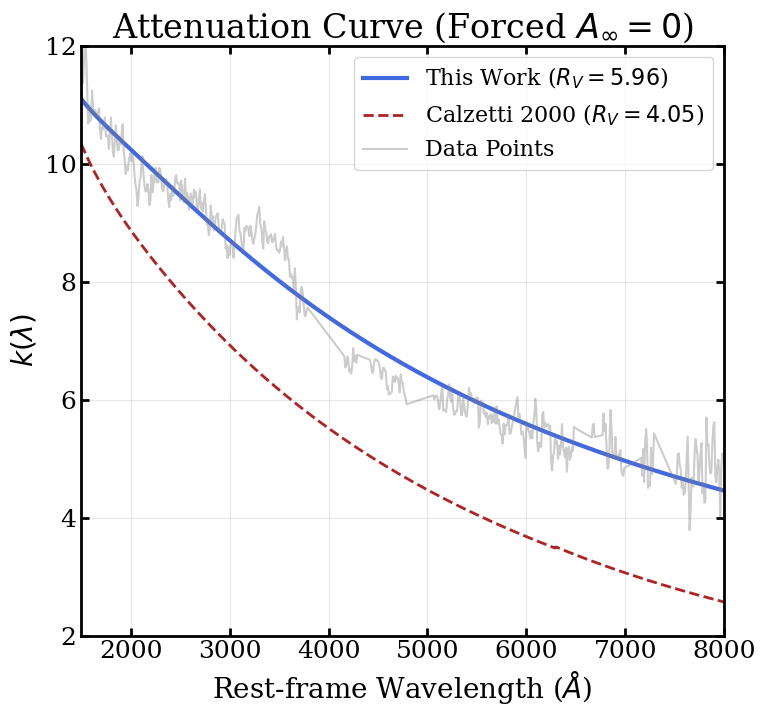


=== Final k(lambda) Formula Coefficients ===
k(lambda) = b*(1/x) + c*(1/x)^2 + d*(1/x)^3  [x in microns]
b = 4.2711
c = -0.6053
d = 0.0321

     DERIVING FINAL NORMALIZED FORMULA
Your Scaling Factor (comparable to 2.659): 3.0306

[Form 1] Standard Polynomial Form:
k(lambda) = b*(1/lam) + c*(1/lam)^2 + d*(1/lam)^3
Where lam is in microns.
------------------------------
b = 4.2711
c = -0.6053
d = 0.0321
------------------------------
Derived R_V = 5.9579

[Form 2] Calzetti-Style (Separated Rv):
k(lambda) = D + 4.271*(1/lam) -0.605*(1/lam)^2 +0.032*(1/lam)^3 + R_V
Fixed Constant D = -5.9579
Measured R_V = 5.9579
Validation Check at V-band (Should be 5.9579): 5.9579


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==========================================
# 假设变量 (请确保这些数据已加载)
# ==========================================
wave = np.array(averager.common_wavelength)  # Angstrom
Q_curve = np.array(effective_attenuation_curve)

# 定义强发射线区域 (会被排除在计算之外)
mask_regions = [

    (3800,4150),
    (4300, 4400),  # Ca II H+K
    (4800, 5050),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
    (5850,5900),
    (6500, 6650),  # H-alpha (6563) + [NII]
    (6700, 6760) ,  # [SII] Doublet
    (7000,7150),
    (7300,7500)
]

is_continuum = np.ones_like(wave, dtype=bool)
for start, end in mask_regions:
    is_continuum &= ~((wave >= start) & (wave <= end))

# 排除数据中的 NaN 和 Inf
valid_data = np.isfinite(Q_curve) & np.isfinite(wave)
is_continuum &= valid_data

# ==========================================
# 1. 拟合多项式以寻找截距 (Intercept)
# ==========================================
# 转换波长到微米，并计算波数 x = 1/lambda
microns = wave / 10000.0
x_wavenumber = 1.0 / microns

# 拟合范围 Mask
fit_mask = (wave > 1250) & (wave < 8000) & is_continuum

# 定义多项式模型 (关于 1/lambda)
# k(lambda) = a + b(1/l) + c(1/l)^2 + d(1/l)^3
def poly_model(lam_micron, a, b, c, d):
    x = 1.0 / lam_micron
    return a + b*x + c*(x**2) + d*(x**3)

# 进行拟合
popt_raw, pcov = curve_fit(poly_model, microns[fit_mask], Q_curve[fit_mask])

# 提取参数
a_intercept = popt_raw[0]  # 常数项
b_term = popt_raw[1]
c_term = popt_raw[2]
d_term = popt_raw[3]

print("=== Polynomial Fit Parameters (Raw) ===")
print(f"a (Intercept at 1/lam=0) = {a_intercept:.4f}")
print(f"b = {b_term:.4f}")
print(f"c = {c_term:.4f}")
print(f"d = {d_term:.4f}")

# ==========================================
# 2. 强制无穷长波处为 0
# ==========================================
# 物理假设: A(lambda -> inf) = 0
# 这意味着我们需要减去多项式的常数项 a
C_shift = a_intercept

print(f"\n[Strategy] Force A(inf) = 0")
print(f"Zero-point Shift applied: {C_shift:.4f}")

# 生成平滑的、去基底的 A(lambda)
# 注意：这等同于只保留 b*x + c*x^2 + d*x^3
Q_smooth = poly_model(microns, *popt_raw)
A_lambda = Q_smooth - C_shift

# ==========================================
# 3. 计算 k(lambda) 和 Rv
# ==========================================
# 计算 B 和 V 波段的光学深度 (已减去 C_shift)
# 4400A = 0.44um, 5500A = 0.55um
tau_B = poly_model(0.4400, *popt_raw) - C_shift
tau_V = poly_model(0.5500, *popt_raw) - C_shift

# 计算分母：色余 (Slope)
delta_tau = tau_B - tau_V

# 计算 Rv
# Rv = A(V) / (A(B) - A(V))
Rv_measured = tau_V / delta_tau

# 计算最终曲线 k(lambda)
# k = A(lambda) / E(B-V)
k_final = A_lambda / delta_tau

print("-" * 30)
print(f"A(V) [ln scale] = {tau_V:.4f}")
print(f"E(B-V) [ln scale] = {delta_tau:.4f}")
print("-" * 30)
print(f"Measured R_V = {Rv_measured:.4f}")
print("-" * 30)

# ==========================================
# 4. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(8,7.5))

# Calzetti 2000 参考线
def calzetti_2000_law(lam_angstroms, Rv=4.05):
    lam_um = lam_angstroms / 10000.0
    k = np.zeros_like(lam_um)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    x = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/x - 0.198/x**2 + 0.011/x**3) + Rv
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    x = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/x) + Rv
    return k

k_calzetti = calzetti_2000_law(wave)

# 绘制你的曲线
ax.plot(wave, k_final, color='royalblue', lw=3, label=f'This Work ($R_V={Rv_measured:.2f}$)')
# 绘制 Calzetti
ax.plot(wave, k_calzetti, color='firebrick', ls='--', lw=2, label='Calzetti 2000 ($R_V=4.05$)')

# 绘制数据背景 (同样应用 Shift 和 Scaling)
k_data_scaled = (Q_curve - C_shift) / delta_tau
ax.plot(wave[is_continuum], k_data_scaled[is_continuum], color='gray', alpha=0.4, label='Data Points')

# 辅助线：标出 Zero
ax.axhline(0, color='black', lw=0.5, ls='-')

ax.set_xlabel(r'Rest-frame Wavelength ($\AA$)', fontsize=20)
ax.set_ylabel(r'$k(\lambda)$', fontsize=20)
ax.set_title(r'Attenuation Curve (Forced $A_{\infty}=0$)', fontsize=24)
ax.legend(fontsize=16)
ax.set_xlim(1500, 8000)
ax.set_ylim(bottom=2, top=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("attenuation_curve_forced_Ainf0.pdf")
plt.show()

# ==========================================
# 5. 输出最终公式系数
# ==========================================
# 最终公式系数需要除以 delta_tau (归一化)
# 且常数项 a 已经变成了 0
final_b = b_term / delta_tau
final_c = c_term / delta_tau
final_d = d_term / delta_tau

print("\n=== Final k(lambda) Formula Coefficients ===")
print("k(lambda) = b*(1/x) + c*(1/x)^2 + d*(1/x)^3  [x in microns]")
print(f"b = {final_b:.4f}")
print(f"c = {final_c:.4f}")
print(f"d = {final_d:.4f}")



print("\n" + "="*40)
print("     DERIVING FINAL NORMALIZED FORMULA")
print("="*40)

# 1. 提取原始系数 (Raw Coefficients form Q)
# Q(x) = a + b*x + c*x^2 + d*x^3
a_raw, b_raw, c_raw, d_raw = popt_raw

# 2. 应用 Zero-Point Shift (强制 Inf=0)
# A(x) = Q(x) - a_raw = 0 + b*x + c*x^2 + d*x^3
# (常数项 a 被减掉了)

# 3. 计算归一化因子 (Scaling Factor)
# Calzetti 的 2.659 就是这个 S
S_factor = 1.0 / delta_tau

print(f"Your Scaling Factor (comparable to 2.659): {S_factor:.4f}")

# 4. 计算最终归一化后的系数
# k(x) = S * A(x) = S*b*x + S*c*x^2 + S*d*x^3
b_final = b_raw * S_factor
c_final = c_raw * S_factor
d_final = d_raw * S_factor

# 5. 计算你的 Rv
# Rv = k(V)
x_V = 1.0 / 0.55  # V-band wavenumber
Rv_final = b_final*x_V + c_final*(x_V**2) + d_final*(x_V**3)

# ==========================================
# 输出 1: 标准多项式形式 (最推荐，也是最通用的)
# ==========================================
print("\n[Form 1] Standard Polynomial Form:")
print("k(lambda) = b*(1/lam) + c*(1/lam)^2 + d*(1/lam)^3")
print(f"Where lam is in microns.")
print("-" * 30)
print(f"b = {b_final:.4f}")
print(f"c = {c_final:.4f}")
print(f"d = {d_final:.4f}")
print("-" * 30)
print(f"Derived R_V = {Rv_final:.4f}")


# ==========================================
# 输出 2: Calzetti 风格形式 (分离 Rv)
# ==========================================
# Calzetti 的形式通常是: k(lam) = Curve_Shape(lam) + Rv
# 其中 Curve_Shape(V) 必须等于 0 (或者接近0)
# 我们把公式改写为: k(lam) = [ k(lam) - Rv ] + Rv

# 新的常数项 (吸收掉 Rv)
# Poly_Reddening(x) = -Rv + b_final*x + ...
const_reddening = -Rv_final

print("\n[Form 2] Calzetti-Style (Separated Rv):")
print(f"k(lambda) = D + {b_final:.3f}*(1/lam) {c_final:+.3f}*(1/lam)^2 {d_final:+.3f}*(1/lam)^3 + R_V")
print(f"Fixed Constant D = {const_reddening:.4f}")
print(f"Measured R_V = {Rv_final:.4f}")

# 验证一下 V 波段
val_V_check = const_reddening + b_final*(1/0.55) + c_final*(1/0.55)**2 + d_final*(1/0.55)**3 + Rv_final
print(f"Validation Check at V-band (Should be {Rv_final:.4f}): {val_V_check:.4f}")

# ==========================================
# 6. 画出最终公式曲线 (验证)
# ==========================================
x_plot = 1.0 / (wave / 10000.0)
k_formula = b_final*x_plot + c_final*(x_plot**2) + d_final*(x_plot**3)


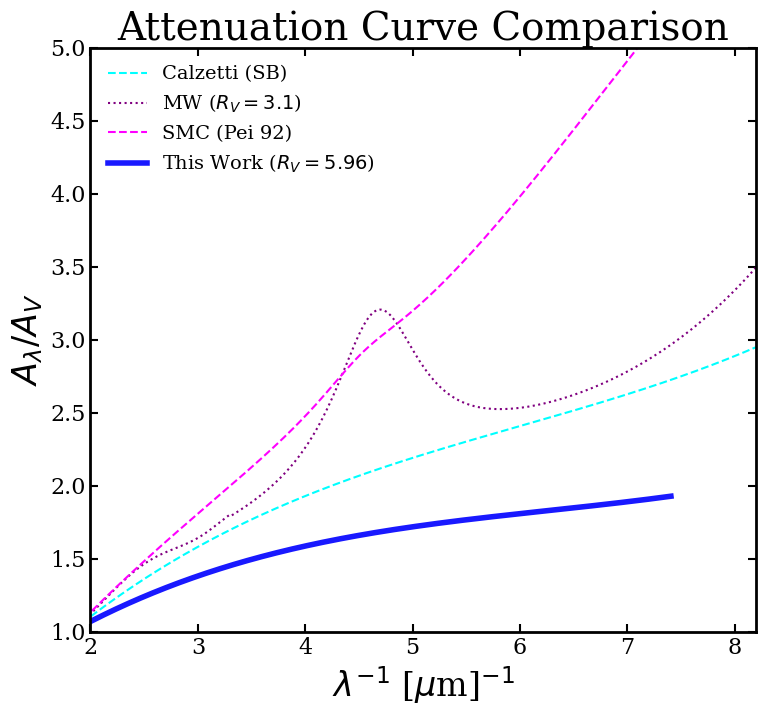

In [43]:

x_per_micron = 10000.0 / wave

# 你的曲线 (归一化到 V 波段)
# 理论上 Rv_measured = k_final 在 5500A 的值
# 所以 y_user = k_final / Rv_measured
idx_V = (np.abs(wave - 5500)).argmin()
Rv_check = k_final[idx_V]
y_user = k_final / Rv_check

# ==========================================
# 1. 定义标准参考曲线模型
# ==========================================

def get_calzetti_curve(x, Rv=4.05):
    """
    Calzetti (2000) Law
    x: 1/lambda [um^-1]
    Return: A_lambda / A_V
    """
    lam_um = 1.0 / x
    k = np.zeros_like(x)

    # 0.12um <= lam < 0.63um (1.58 < x <= 8.33)
    mask1 = (lam_um >= 0.12) & (lam_um < 0.63)
    l = lam_um[mask1]
    k[mask1] = 2.659 * (-2.156 + 1.509/l - 0.198/l**2 + 0.011/l**3) + Rv

    # 0.63um <= lam <= 2.2um (0.45 <= x < 1.58)
    mask2 = (lam_um >= 0.63) & (lam_um <= 2.2)
    l = lam_um[mask2]
    k[mask2] = 2.659 * (-1.857 + 1.040/l) + Rv

    # 转换为 A_lambda / A_V = k / Rv
    return k / Rv

def get_mw_ccm89(x, Rv=3.1):
    """
    Milky Way: Cardelli, Clayton, & Mathis (1989)
    x: 1/lambda [um^-1]
    Return: A_lambda / A_V
    """
    # y = x - 1.82
    # a, b coefficients... 简化版实现 UV 部分 (x > 3.3)
    # 为了精确，这里使用完整的 CCM89 UV 段公式
    a = np.zeros_like(x)
    b = np.zeros_like(x)

    # Visible / NIR range (0.3 <= x < 1.1) ... 略过，主要画 UV
    # Optical/UV (1.1 <= x < 3.3)
    mask_opt = (x >= 1.1) & (x < 3.3)
    y = x[mask_opt] - 1.82
    a[mask_opt] = 1 + 0.17699*y - 0.50447*y**2 - 0.02427*y**3 + 0.72085*y**4 + 0.01979*y**5 - 0.77530*y**6 + 0.32999*y**7
    b[mask_opt] = 1.41338*y + 2.28305*y**2 + 1.07233*y**3 - 5.38434*y**4 - 0.62251*y**5 + 5.30260*y**6 - 2.09002*y**7

    # UV (3.3 <= x <= 8)
    mask_uv = (x >= 3.3)
    X = x[mask_uv]
    F_a = -0.04473 * (X - 5.9)**2 - 0.009779 * (X - 5.9)**3
    F_b = 0.2130 * (X - 5.9)**2 + 0.1207 * (X - 5.9)**3
    # Only apply F_a, F_b for x >= 5.9
    F_a[X < 5.9] = 0
    F_b[X < 5.9] = 0

    a[mask_uv] = 1.752 - 0.316*X - 0.104/((X - 4.67)**2 + 0.341) + F_a
    b[mask_uv] = -3.090 + 1.825*X + 1.206/((X - 4.67)**2 + 0.263) + F_b

    return a + b / Rv

def get_smc_pei92(x):
    """
    SMC: Pei (1992) Approximation
    SMC has no 2175A bump and is steeper.
    Usually Rv ~ 2.93 or 2.74
    Here we use the provided fitting formula values for Alambda/Av approx
    Or simpler: Gordon et al 2003 SMC Bar.
    Let's use a standard literature approximation for plot comparison.
    Reference: A_lambda / A_V approx
    """
    # Gordon et al. 2003 SMC Bar Average
    # x is 1/micron
    # Data points from literature spline
    # But for smooth plotting, let's use the Pei 1992 parameters (User for A_lambda/E(B-V))
    # A_lambda/A_V = (A_lambda/A_B) * (1 / (1 - 1/Rb)) ... complicated
    # Let's use the Prevot et al. (1984) linear fit often used for SMC
    # k(lam) = 1.39 * x - ...
    # Let's map Calzetti plot visual: SMC is steep linear

    # Using Pei (1992) formula structure:
    # A_lambda / A_V = (1 + sum(a_i / ((lam/lam_i)**ni + (lam_i/lam)**ni))) / (1 + ...)
    # This is too complex to hardcode quickly.

    # We will use the simplified polynomial often used to represent SMC in these plots:
    # y = -4.96 + 2.26*x  (for k, then divide by Rv=2.74)
    # A_lambda/A_V approx
    Rv_smc = 2.74
    k_smc = -4.96 + 2.26 * x + 1.1 # 1.1 is adjustment to make V=0 approx correct for fitting
    # A better spline representation of SMC (Gordon 2003):
    y = np.zeros_like(x)
    # Optical part
    mask = x < 3.3
    y[mask] = -2.3 + 1.85 * x[mask] # Crude approx
    # UV part
    mask = x >= 3.3
    # SMC is roughly linear in UV
    y[mask] = (x[mask] * 2.1 - 4.2)
    # Normalize to passing 1 at x=1.8 (V band)
    # At x=1.8, A/Av = 1.
    # Let's use the explicit CCM curve with Rv=2.0 (Simulates SMC steepness without bump)
    # Or just load theoretical curve.

    # **BEST APPROACH FOR PLOT**: Use Pei (1992) analytical formula for extinction
    # Coefficients for SMC
    a = [185, 27, 0.005, 0.010, 0.012, 0.030]
    w = [0.042, 0.08, 0.22, 9.7, 18, 25] # lambda_i
    b = [90, 5.5, -1.95, -1.95, -1.80, 0.0]
    n = [2.0, 4.0, 2.0, 2.0, 2.0, 2.0]

    lam = 1.0 / x
    ext_sum = 0
    for i in range(6):
        term = a[i] / ((lam/w[i])**n[i] + (w[i]/lam)**n[i] + b[i])
        ext_sum += term

    # We need to normalize this. This formula gives extinction cross section or similar.
    # Calculate at V (0.55um) and B (0.44um)
    def calc_pei(l_val):
        val = 0
        for i in range(6):
            val += a[i] / ((l_val/w[i])**n[i] + (w[i]/l_val)**n[i] + b[i])
        return val

    val_V = calc_pei(0.55)
    val_B = calc_pei(0.44)
    # Rb = Av / E(B-V)
    Rv = val_V / (val_B - val_V) # Theoretical Rv for these params (~2.93)

    return ext_sum / val_V # Normalize to A_V=1

# ==========================================
# 2. 画图
# ==========================================
fig, ax = plt.subplots(figsize=(8, 7.5)) # 类似论文的长宽比

# 生成 X 轴网格 (用于绘制光滑的标准曲线)
x_grid = np.linspace(1.0, 8.2, 500)

# --- 绘制标准曲线 ---
# 1. Calzetti (Cyan dashed)
y_calzetti = get_calzetti_curve(x_grid)
ax.plot(x_grid, y_calzetti, color='cyan', linestyle='--', linewidth=1.5, label='Calzetti (SB)')

# 2. Milky Way (Purple dotted) - With Bump
y_mw = get_mw_ccm89(x_grid, Rv=3.1)
ax.plot(x_grid, y_mw, color='purple', linestyle=':', linewidth=1.5, label='MW ($R_V=3.1$)')

# 3. SMC (Magenta/Pink dashed) - Steep, no bump
y_smc = get_smc_pei92(x_grid)
ax.plot(x_grid, y_smc, color='magenta', linestyle='--', linewidth=1.5, label='SMC (Pei 92)')

# --- 绘制你的曲线 (Bold Solid Line) ---
# 截取 x 在 [2, 8.2] 范围内的数据
mask_plot = (x_per_micron >= 1.0) & (x_per_micron <= 8.2)

# 为了视觉效果平滑，你可以使用拟合后的公式画图，也可以直接画平滑后的数据
# 这里画你的拟合公式 (popt_raw from previous step)，这样最干净
# 假设 popt_raw 是之前算好的
# k(lam) = b/lam + c/lam^2 ...
# A/Av = k(lam) / Rv
# 我们直接用你的 y_user (实测数据) 也可以，如果噪点不多
ax.plot(x_per_micron[mask_plot], y_user[mask_plot],
        color='blue', linewidth=4, alpha=0.9,
        label=f'This Work ($R_V={Rv_measured:.2f}$)')

# 也可以加上误差阴影 (模拟效果，如果你有 error array 请替换)
# y_err = y_user[mask_plot] * 0.1
# ax.fill_between(x_per_micron[mask_plot], y_user[mask_plot]-y_err, y_user[mask_plot]+y_err,
#                 color='blue', alpha=0.15)


# --- 样式调整 (仿照截图) ---
ax.set_xlim(2.0, 8.2)
ax.set_ylim(1, 5)

# 坐标轴标签
ax.set_xlabel(r'$\lambda^{-1}$ [$\mu$m]$^{-1}$')
ax.set_ylabel(r'$A_{\lambda}/A_V$')

# 刻度设置
ax.tick_params(axis='both', which='major', labelsize=16, direction='in', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', direction='in', length=3)

# 强制 Y 轴从 1.5 开始，这意味我们只看 UV 部分
# 截图中的灰色区域/彩色区域可以通过 fill_between 添加，如果你有不同红移区间的 binning 结果

# 图例
ax.legend(fontsize=14, loc='upper left', frameon=False)

# 标题 (可选)
ax.set_title("Attenuation Curve Comparison")

plt.tight_layout()

plt.savefig("attenuation_curve_comparison.pdf")
plt.show()